# Como ultilizar

Antes de rodar crie um ambiente virtal e ative.  
Instalar o Poetry  
Executar o comando poetry lock  
Executar o comando poetry install  

# Imports

In [140]:
import warnings
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import zscore
from statsmodels.tsa.seasonal import STL
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import phik
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import TimeSeriesFold, backtesting_forecaster
from sklearn.linear_model import LinearRegression, ElasticNet, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from scipy.optimize import curve_fit, differential_evolution
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import HillClimbSearch, BIC, MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
import networkx as nx

pds = pandas series  
df = DataFrame

In [141]:
warnings.filterwarnings("ignore", message="Covariance matrix calculated using the outer product")


# Preparando o Data Frame

In [142]:
pd.options.display.float_format = '{:.2f}'.format

In [143]:
abas  = pd.ExcelFile('WDI_EXCEL/WDIEXCEL.xlsx').sheet_names
abas

['Data', 'Country', 'Series', 'country-series', 'series-time', 'footnote']

In [144]:
metadata = pd.read_excel('WDI_EXCEL/WDIEXCEL.xlsx', sheet_name=abas[2])
metadata.head()

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type
0,AG.CON.FERT.PT.ZS,Environment: Agricultural production,Fertilizer consumption (% of fertilizer produc...,NaN,Fertilizer consumption measures the quantity o...,NaN,Annual,NaN,The world and regional aggregate series do not...,Weighted average,The FAO has revised the time series for fertil...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Fertilizer consumption measures the quantity o...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0
1,AG.CON.FERT.ZS,Environment: Agricultural production,Fertilizer consumption (kilograms per hectare ...,NaN,Fertilizer consumption measures the quantity o...,NaN,Annual,NaN,The world and regional aggregate series do not...,Weighted average,The FAO has revised the time series for fertil...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Fertilizer consumption measures the quantity o...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0
2,AG.LND.AGRI.K2,Environment: Land use,Agricultural land (sq. km),NaN,Agricultural land refers to the share of land ...,NaN,Annual,NaN,Areas of former states are included in the suc...,Sum,The data are collected by the Food and Agricul...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Agricultural land constitutes only a part of a...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0
3,AG.LND.AGRI.ZS,Environment: Land use,Agricultural land (% of land area),NaN,Agricultural land refers to the share of land ...,NaN,Annual,NaN,Areas of former states are included in the suc...,Weighted average,The data are collected by the Food and Agricul...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Agriculture is still a major sector in many ec...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0
4,AG.LND.ARBL.HA,Environment: Land use,Arable land (hectares),NaN,Arable land (in hectares) includes land define...,NaN,Annual,NaN,NaN,NaN,The Food and Agriculture Organization (FAO) tr...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Temporary fallow land refers to land left fall...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0


In [145]:
metadata.columns = [col.strip().replace("_", " ") for col in metadata.columns]

In [146]:
metadata["Topic"].nunique()

88

In [147]:
lista_metadata = list(metadata["Topic"].unique())

In [148]:
metadata["Indicator Name"].nunique()

1496

In [149]:
dados = pd.read_excel('WDI_EXCEL/WDIEXCEL.xlsx', sheet_name=abas[0])
dados.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,17.49,18.00,18.56,19.04,19.59,20.19,20.83,21.37,22.10,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,6.81,7.10,7.41,7.67,8.02,8.40,8.72,9.10,9.47,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.15,38.49,38.78,39.07,39.45,39.82,40.28,40.69,41.21,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,31.87,33.92,38.86,40.22,43.04,44.39,46.28,48.13,48.74,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,17.67,16.53,24.63,25.43,27.06,29.15,31.02,32.81,33.76,NaN


In [150]:
dados.columns = [col.strip().replace("_", " ") for col in dados.columns]

In [151]:
print(dados.columns)


Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023'],
      dtype='object')


In [152]:
dados["Indicator Name"].nunique()

1496

In [153]:
dados_long = dados.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="Year",
    value_name="Value"
)

In [154]:
dados_long["Year"] = dados_long["Year"].astype(int)

In [155]:
dados_long.dtypes

Country Name       object
Country Code       object
Indicator Name     object
Indicator Code     object
Year                int64
Value             float64
dtype: object

## Separando por paises e comaçando a olhar o data frame do Brasil

Separação feita desta maneira para uma posssivel extrapolação para demais paises futuramente

In [156]:
paises_unicos = dados_long["Country Name"].unique()

sub_dfs_por_pais = {
    pais: grupo.drop(columns=["Country Code", "Country Name"]).reset_index(drop=True)
    for pais, grupo in dados_long.groupby("Country Name")
}

brasil = sub_dfs_por_pais["Brazil"]
print("\nDados do Brasil:")
brasil.head()


Dados do Brasil:


,Indicator Name,Indicator Code,Year,Value
0,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,1960,NaN
1,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,1960,NaN
2,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,1960,NaN
3,Access to electricity (% of population),EG.ELC.ACCS.ZS,1960,NaN
4,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,1960,NaN


# Limpando DF Brasil

### Primeira Visualização

In [157]:
# 1. Filtrar apenas as colunas importantes para a pivotagem
df_brasil = brasil[["Year", "Indicator Name", "Value"]].copy()

# 2. Pivotar para ficar no formato "wide" (uma coluna por indicador)
df_brasil_wide = df_brasil.pivot(
    index="Year",
    columns="Indicator Name",
    values="Value"
)

# 3. Ordenar pelas datas (anos) e exibir as primeiras linhas
df_brasil_wide.sort_index(inplace=True)
df_brasil_wide.head()

Indicator Name,ARI treatment (% of children under 5 taken to a health provider),Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),"Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)","Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)",...,Women who believe a husband is justified in beating his wife (any of five reasons) (%),Women who believe a husband is justified in beating his wife when she argues with him (%),Women who believe a husband is justified in beating his wife when she burns the food (%),Women who believe a husband is justified in beating his wife when she goes out without telling him (%),Women who believe a husband is justified in beating his wife when she neglects the children (%),Women who believe a husband is justified in beating his wife when she refuses sex with him (%),Women who were first married by age 15 (% of women ages 20-24),Women who were first married by age 18 (% of women ages 20-24),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
Year,,,,,,,,,,,,,,,,,,,,,
1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [158]:
pds_br_tps = df_brasil_wide.dtypes
for i ,formato in pds_br_tps.items():
    if formato != 'float64' and formato != 'int64':
        print(i, formato)

In [159]:
# Informações gerais sobre nulos e dimensões
linhas, colunas = df_brasil_wide.shape
total_celulas = linhas * colunas
total_nulos = df_brasil_wide.isnull().sum().sum()
porcentagem_nulos = (total_nulos / total_celulas) * 100

print(f"Linhas: {linhas}")
print(f"Colunas: {colunas}")
print(f"Total de valores nulos: {total_nulos}")


Linhas: 64
Colunas: 1496
Total de valores nulos: 49579


### Verificando quantidade de nulos por indicador

In [160]:
# Contar valores nulos por linha
pds_nulos_por_indicador = df_brasil_wide.isna().sum(axis=0)

# Exibir o resultado
print("Quantidade de valores nulos por linha (ano):")
print(pds_nulos_por_indicador.sort_values(ascending=False))

Quantidade de valores nulos por linha (ano):
Indicator Name
Women who believe a husband is justified in beating his wife when she refuses sex with him (%)       64
Vitamin A supplementation coverage rate (% of children ages 6-59 months)                             64
Young people (ages 15-24) newly infected with HIV                                                    64
Educational attainment, at least completed post-secondary, population 25+, male (%) (cumulative)     64
Educational attainment, at least completed post-secondary, population 25+, total (%) (cumulative)    64
                                                                                                     ..
Terms of trade adjustment (constant LCU)                                                              0
Agriculture, forestry, and fishing, value added (constant 2015 US$)                                   0
Agriculture, forestry, and fishing, value added (constant LCU)                                        0
Agri

In [161]:
pds_nulos_por_indicador = pds_nulos_por_indicador.sort_values(ascending=False)
indicadroes_sem_dados = []
for indicador, valor in pds_nulos_por_indicador.items():
    if valor == 64:
        indicadroes_sem_dados.append(indicador)
print(len(indicadroes_sem_dados))

102


In [162]:
df_brasil_wide = df_brasil_wide.drop(columns=indicadroes_sem_dados)
df_brasil_wide.head()

Indicator Name,ARI treatment (% of children under 5 taken to a health provider),Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),"Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)","Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)",...,"Wage and salaried workers, female (% of female employment) (modeled ILO estimate)","Wage and salaried workers, male (% of male employment) (modeled ILO estimate)","Wage and salaried workers, total (% of total employment) (modeled ILO estimate)",Wanted fertility rate (births per woman),"Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)",Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100),Women who were first married by age 15 (% of women ages 20-24),Women who were first married by age 18 (% of women ages 20-24),Women's share of population ages 15+ living with HIV (%)
Year,,,,,,,,,,,,,,,,,,,,,
1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN
1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN
1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN
1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN
1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN


In [163]:
# Substituir zeros por NaN (sem alterar o original ainda)
df_temp = df_brasil_wide.replace(0, np.nan)

# Contar valores nulos (incluindo os zeros que viraram NaN) por coluna
pds_nulos_por_indicador = df_temp.isna().sum(axis=0)

# Ordenar indicadores com mais "dados faltantes"
pds_nulos_por_indicador = pds_nulos_por_indicador.sort_values(ascending=False)

# Selecionar indicadores com >= 30% de valores faltantes
limite = df_brasil_wide.shape[0] * 0.3  # 30% do total de anos (ex: 64)
indicadores_remover = [
    indicador for indicador, nulos in pds_nulos_por_indicador.items()
    if nulos >= limite
]

print(f"{len(indicadores_remover)} indicadores com >= 30% de NaNs ou Zeros")


911 indicadores com >= 30% de NaNs ou Zeros


In [164]:
df_brasil_wide = df_brasil_wide.drop(columns=indicadores_remover)
df_brasil_wide.head()

Indicator Name,Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted net national income (current US$),Adjusted net national income per capita (annual % growth),Adjusted net national income per capita (constant 2015 US$),Adjusted net national income per capita (current US$),Adjusted savings: consumption of fixed capital (% of GNI),Adjusted savings: consumption of fixed capital (current US$),Adjusted savings: education expenditure (% of GNI),Adjusted savings: education expenditure (current US$),...,Travel services (% of commercial service exports),Travel services (% of commercial service imports),"Travel services (% of service exports, BoP)","Travel services (% of service imports, BoP)","Unemployment, total (% of total labor force) (national estimate)",Urban population,Urban population (% of total population),Urban population growth (annual %),Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100)
Year,,,,,,,,,,,,,,,,,,,,,
1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,33399157.00,46.14,NaN,0.00,NaN
1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,35155579.00,47.12,5.13,0.00,NaN
1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,36971452.00,48.10,5.04,0.00,NaN
1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,38852223.00,49.08,4.96,0.00,NaN
1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,40792376.00,50.06,4.87,0.00,NaN


### Verificando quantidade de nulos por ano

In [165]:
# Contar valores nulos por linha
pds_nulos_por_ano = df_brasil_wide.isna().sum(axis=1)

# Exibir o resultado
print("Quantidade de valores nulos por linha (ano):")
print(pds_nulos_por_ano)

Quantidade de valores nulos por linha (ano):
Year
1960    257
1961    219
1962    205
1963    203
1964    202
       ... 
2019      6
2020      6
2021     31
2022     65
2023    133
Length: 64, dtype: int64


In [166]:
pds_nulos_por_ano = pds_nulos_por_ano.sort_values(ascending=False)
anos_remover = []
for indicador, valor in pds_nulos_por_ano.items():
    if valor >= (497*0.3):
        anos_remover.append(indicador)
print(len(anos_remover))

10


In [167]:
anos_remover.sort()
anos_remover

[1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969]

In [168]:
df_brasil_wide = df_brasil_wide.drop(labels=anos_remover, axis=0)
df_brasil_wide.head()

Indicator Name,Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted net national income (current US$),Adjusted net national income per capita (annual % growth),Adjusted net national income per capita (constant 2015 US$),Adjusted net national income per capita (current US$),Adjusted savings: consumption of fixed capital (% of GNI),Adjusted savings: consumption of fixed capital (current US$),Adjusted savings: education expenditure (% of GNI),Adjusted savings: education expenditure (current US$),...,Travel services (% of commercial service exports),Travel services (% of commercial service imports),"Travel services (% of service exports, BoP)","Travel services (% of service imports, BoP)","Unemployment, total (% of total labor force) (national estimate)",Urban population,Urban population (% of total population),Urban population growth (annual %),Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100)
Year,,,,,,,,,,,,,,,,,,,,,
1970,NaN,329110917867.01,37827671711.72,NaN,3450.68,396.62,9.12,3806293433.50,3.60,1501928756.85,...,NaN,NaN,NaN,NaN,NaN,53323573.00,55.91,4.22,0.00,31.25
1971,11.84,368091817815.40,44189749778.58,9.14,3766.06,452.12,9.02,4390515966.53,3.60,1752280062.53,...,NaN,NaN,NaN,NaN,NaN,55607782.00,56.89,4.19,0.00,31.25
1972,12.51,414137990307.36,52697250476.70,9.80,4135.31,526.20,9.03,5243614438.53,3.60,2090295462.24,...,NaN,NaN,NaN,NaN,3.06,57963965.00,57.88,4.15,0.00,31.25
1973,14.29,473324364054.23,70746869157.10,11.56,4613.25,689.53,9.50,7446977712.89,3.00,2351424238.06,...,NaN,NaN,NaN,NaN,2.78,60385804.00,58.85,4.09,0.00,31.25
1974,6.15,502447269353.97,93522157853.13,3.64,4781.13,889.93,9.75,10171165701.52,3.60,3754972094.08,...,NaN,NaN,NaN,NaN,NaN,62870949.00,59.83,4.03,0.00,28.12


In [169]:
df_brasil_wide.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54 entries, 1970 to 2023
Columns: 483 entries, Adjusted net national income (annual % growth) to Women Business and the Law Index Score (scale 1-100)
dtypes: float64(483)
memory usage: 204.2 KB


In [170]:
df_brasil_wide.describe()

Indicator Name,Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted net national income (current US$),Adjusted net national income per capita (annual % growth),Adjusted net national income per capita (constant 2015 US$),Adjusted net national income per capita (current US$),Adjusted savings: consumption of fixed capital (% of GNI),Adjusted savings: consumption of fixed capital (current US$),Adjusted savings: education expenditure (% of GNI),Adjusted savings: education expenditure (current US$),...,Travel services (% of commercial service exports),Travel services (% of commercial service imports),"Travel services (% of service exports, BoP)","Travel services (% of service imports, BoP)","Unemployment, total (% of total labor force) (national estimate)",Urban population,Urban population (% of total population),Urban population growth (annual %),Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100)
count,51.00,52.00,52.00,51.00,52.00,52.00,52.00,52.00,52.00,52.00,...,49.00,49.00,49.00,49.00,45.00,54.00,54.00,54.00,52.00,54.00
mean,3.01,916226764655.22,668106193098.04,1.43,5590.58,3682.08,14.46,146116777173.56,4.42,42878124262.17,...,17.10,19.29,16.32,18.16,7.39,125683348.17,75.95,2.39,51.56,57.06
std,6.37,330404553335.56,591598806535.58,6.13,916.29,2801.14,3.95,164533673633.21,0.98,45719277437.73,...,9.43,7.15,9.00,7.02,3.47,41767312.44,9.72,1.18,66.12,22.27
min,-14.62,329110917867.01,37827671711.72,-16.13,3450.68,396.62,9.02,3806293433.50,2.80,1501928756.85,...,2.37,6.65,2.26,5.90,1.92,53323573.00,55.91,0.63,0.00,28.12
25%,-0.21,644598697476.69,192597559491.62,-1.65,4987.95,1490.70,11.79,24320077207.31,3.60,7718184159.73,...,7.54,14.73,7.25,13.30,4.04,89218136.00,68.36,1.20,0.00,33.12
50%,3.10,930726733007.78,443486926459.94,1.28,5542.38,2537.68,13.76,76987042335.75,4.26,20631839915.97,...,17.81,19.94,17.32,18.48,7.58,130158294.00,78.68,2.42,21.92,50.62
75%,5.88,1271164706883.42,1160584530598.46,4.06,6433.40,5848.70,15.72,252705735210.03,5.22,84565276842.99,...,23.86,24.34,22.05,22.86,10.15,162876810.00,84.26,3.51,94.64,81.88
max,22.52,1435186247693.20,2003637158343.32,20.44,7230.95,10260.08,23.06,518751321168.80,6.28,139938624966.18,...,39.87,35.95,39.08,34.50,13.70,185356223.00,87.79,4.22,275.21,85.00


### Variaveis Constantes

In [171]:
# Selecionar colunas onde a variância é diferente de zero, ou seja, não são constantes
cols_to_keep = df_brasil_wide.loc[:, df_brasil_wide.nunique() > 1].columns

# Criar um novo DataFrame sem as colunas constantes
df_brasil_wide = df_brasil_wide[cols_to_keep]

print(f"\n{len(df_brasil_wide.columns)} variáveis restantes após remoção de constantes.")


479 variáveis restantes após remoção de constantes.


### Verificando indicadores redundantes

In [172]:
new_df_brasil_wide = df_brasil_wide.copy()
colunas_preservadas = new_df_brasil_wide[['Population growth (annual %)', 'Population, total']].copy()

In [173]:
new_df_brasil_wide = new_df_brasil_wide.drop(colunas_preservadas, axis=1)

In [174]:
# Preencher NaNs (por exemplo com interpolação linear)
df = new_df_brasil_wide.interpolate(method='linear', limit_direction='both')

# Padronizar os dados
df_zscore = df.apply(zscore)

# Função para calcular a correlação cruzada entre duas séries
def max_cross_corr(series1, series2, max_lag=5):
    lags = range(-max_lag, max_lag + 1)
    corrs = [series1.corr(series2.shift(lag)) for lag in lags]
    max_corr = max(corrs, key=abs)
    return max_corr

# Parâmetros
threshold = 0.9  # Correlação cruzada acima desse valor será considerada redundância
max_lag = 5      # Número máximo de anos de defasagem

# Detectar pares altamente correlacionados com defasagem
to_remove = set()
columns = df_zscore.columns.tolist()

for i, col1 in enumerate(columns):
    for col2 in columns[i+1:]:
        corr = max_cross_corr(df_zscore[col1], df_zscore[col2], max_lag=max_lag)
        if abs(corr) > threshold:
            to_remove.add(col2)

# Remover colunas redundantes
new_df_brasil_wide = df.drop(columns=to_remove)

print(f"\n{len(to_remove)} variáveis removidas por correlação cruzada.")


345 variáveis removidas por correlação cruzada.


###  Verificando df

In [175]:
new_df_brasil_wide = pd.concat([new_df_brasil_wide, colunas_preservadas], axis=1)

In [176]:
new_df_brasil_wide.head()

Indicator Name,Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted savings: education expenditure (% of GNI),Adjusted savings: energy depletion (% of GNI),Adjusted savings: gross savings (% of GNI),Adjusted savings: mineral depletion (% of GNI),Adjusted savings: net national savings (% of GNI),Adjusted savings: net national savings (current US$),"Adolescent fertility rate (births per 1,000 women ages 15-19)",Agricultural land (% of land area),...,Short-term debt (% of total external debt),Short-term debt (% of total reserves),Surface area (sq. km),Terms of trade adjustment (constant LCU),Total debt service (% of GNI),"Total debt service (% of exports of goods, services and primary income)",Travel services (% of commercial service exports),Travel services (% of commercial service imports),Population growth (annual %),"Population, total"
Year,,,,,,,,,,,,,,,,,,,,,
1970,11.84,329110917867.01,3.60,0.05,21.84,0.18,11.21,13677216371.16,75.07,22.77,...,11.93,60.01,8515770.00,13852216117.28,1.84,43.83,7.26,17.63,2.47,95375651.00
1971,11.84,368091817815.40,3.60,0.07,21.84,0.14,11.21,13677216371.16,76.73,23.19,...,11.95,52.63,8515770.00,10676889017.00,1.81,43.83,7.26,17.63,2.45,97739273.00
1972,12.51,414137990307.36,3.60,0.07,21.84,0.17,11.21,13677216371.16,79.21,23.61,...,11.93,33.54,8515770.00,13931598427.89,2.07,43.83,7.26,17.63,2.43,100146797.00
1973,14.29,473324364054.23,3.00,0.09,21.84,0.15,11.21,13677216371.16,80.86,24.03,...,11.95,27.67,8515770.00,27871882878.70,2.45,43.83,7.26,17.63,2.42,102600976.00
1974,6.15,502447269353.97,3.60,0.39,21.84,0.22,11.21,13677216371.16,81.32,24.45,...,12.03,49.46,8515770.00,8881354018.93,3.28,43.83,7.26,17.63,2.40,105089675.00


In [177]:
# 1) Ver a lista completa
new_df_brasil_wide.columns          # retorna um Index

# 2) Transformar em lista Python
indicadores = new_df_brasil_wide.columns.tolist()
print(indicadores)

# 3) Mostrar uma por linha (útil quando são muitas)
for col in new_df_brasil_wide.columns:
    print(col)

# 4) Resumo rápido
new_df_brasil_wide.info()           # mostra nº de colunas e tipos


['Adjusted net national income (annual % growth)', 'Adjusted net national income (constant 2015 US$)', 'Adjusted savings: education expenditure (% of GNI)', 'Adjusted savings: energy depletion (% of GNI)', 'Adjusted savings: gross savings (% of GNI)', 'Adjusted savings: mineral depletion (% of GNI)', 'Adjusted savings: net national savings (% of GNI)', 'Adjusted savings: net national savings (current US$)', 'Adolescent fertility rate (births per 1,000 women ages 15-19)', 'Agricultural land (% of land area)', 'Agricultural raw materials exports (% of merchandise exports)', 'Agricultural raw materials imports (% of merchandise imports)', 'Agriculture, forestry, and fishing, value added (annual % growth)', 'Arable land (hectares per person)', 'Arms exports (SIPRI trend indicator values)', 'Arms imports (SIPRI trend indicator values)', 'Average precipitation in depth (mm per year)', 'Broad money (% of GDP)', 'Broad money growth (annual %)', 'Broad money to total reserves ratio', 'Capture f

In [178]:
new_df_brasil_wide.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54 entries, 1970 to 2023
Columns: 134 entries, Adjusted net national income (annual % growth) to Population, total
dtypes: float64(134)
memory usage: 57.0 KB


In [179]:
# Informações gerais sobre nulos e dimensões
linhas, colunas = new_df_brasil_wide.shape
total_celulas = linhas * colunas
total_nulos = new_df_brasil_wide.isnull().sum().sum()
porcentagem_nulos = (total_nulos / total_celulas) * 100

print(f"Linhas: {linhas}")
print(f"Colunas: {colunas}")
print(f"Total de valores nulos: {total_nulos}")


Linhas: 54
Colunas: 134
Total de valores nulos: 0


# Análise Exploratória

## Agrupamento de topicos

### Topico com subtopico

In [180]:
# Filtra indicadores da metadata que estão no df_brasil_wide
metadata_filtered = metadata[metadata["Indicator Name"].isin(new_df_brasil_wide.columns)]

# Agrupa por tópico
agrupamentos_por_topico = (
    metadata_filtered.groupby("Topic")["Indicator Name"]
    .apply(list)
    .to_dict()
)


In [181]:
x = []
for topico in agrupamentos_por_topico.keys():
    z = []
    for item in agrupamentos_por_topico[topico]:
      z.append(item)
    x.append(len(z))
print(x)

[5, 3, 1, 2, 1, 8, 1, 11, 8, 8, 1, 3, 9, 2, 18, 2, 1, 1, 5, 2, 4, 1, 3, 1, 2, 1, 9, 8, 3, 1]


In [182]:
# 3. Cria um dicionário de DataFrames por tópico
dfs_por_topico = {}

for topico, indicadores in agrupamentos_por_topico.items():
    # Garante que os indicadores existem no DataFrame
    indicadores_validos = [ind for ind in indicadores if ind in new_df_brasil_wide.columns]

    if indicadores_validos:
        df_topico = new_df_brasil_wide[indicadores_validos].copy()
        dfs_por_topico[topico] = df_topico


In [183]:
diagnostico_topico = []

for topico, df in dfs_por_topico.items():
    df_clean = df.dropna(axis=1, how='all').dropna()  # remove colunas completamente nulas e linhas com NA

    if df_clean.empty:
        continue

    # Padroniza os dados
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns)

    # Contagem total de outliers (z-score > 3)
    outliers_mask = df_scaled.abs() > 3
    n_outliers_total = outliers_mask.sum().sum()

    # Quantas variáveis têm ao menos 1 outlier
    n_vars_outlier = (outliers_mask.sum() > 0).sum()
    pct_vars_outlier = round((n_vars_outlier / len(df_clean)), 2)

    # Correlações
    try:
        corr_matrix = df_scaled.corr().abs()
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        n_corr_alta = (upper_tri > 0.9).sum().sum()
        n_vars = df_scaled.shape[1]
        if n_vars <= 1:
            per_cent_corr = 0.0
        else:
            total_possible = n_vars * (n_vars - 1) / 2
            per_cent_corr = round((n_corr_alta / total_possible) * 100, 2)
    except:
        per_cent_corr = None

    diagnostico_topico.append({
        'Topico': topico,
        'N_Variáveis': df.shape[1],
        'N_Observações': df.shape[0],
        '% Missing': round(df.isnull().mean().mean() * 100, 2),
        '% correlações > 0.9': per_cent_corr,
        'N_Outliers (z > 3)': int(n_outliers_total),
        '% Variáveis com Outliers': pct_vars_outlier
    })

df_diag = pd.DataFrame(diagnostico_topico).sort_values('Topico', ascending=True).reset_index(drop=True)
df_diag

,Topico,N_Variáveis,N_Observações,% Missing,% correlações > 0.9,N_Outliers (z > 3),% Variáveis com Outliers
0,Economic Policy & Debt: Balance of payments: C...,5,54,0.00,0.00,5,0.07
1,Economic Policy & Debt: Balance of payments: C...,3,54,0.00,0.00,2,0.04
2,Economic Policy & Debt: Balance of payments: C...,1,54,0.00,0.00,0,0.00
3,Economic Policy & Debt: Balance of payments: C...,2,54,0.00,0.00,0,0.00
4,Economic Policy & Debt: Balance of payments: R...,1,54,0.00,0.00,1,0.02
5,Economic Policy & Debt: External debt: Debt ra...,8,54,0.00,0.00,3,0.06
6,Economic Policy & Debt: External debt: Debt se...,1,54,0.00,0.00,1,0.02
7,Economic Policy & Debt: External debt: Net flows,11,54,0.00,0.00,18,0.20
8,Economic Policy & Debt: National accounts: Adj...,8,54,0.00,0.00,5,0.06
9,Economic Policy & Debt: National accounts: Gro...,8,54,0.00,0.00,5,0.09


### Topicos macros

In [184]:
dfs_por_macrotema = defaultdict(list)

for topico, df in dfs_por_topico.items():
    macrotema = topico.split(':')[0].strip()
    dfs_por_macrotema[macrotema].append(df)


In [185]:
dfs_macrotema_unificado = {}

for macrotema, lista_dfs in dfs_por_macrotema.items():
    df_merged = pd.concat(lista_dfs, axis=1)
    # Remove colunas duplicadas (caso haja) e mantém ordem
    df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()]
    dfs_macrotema_unificado[macrotema] = df_merged

In [186]:
diagnostico_macrotema = []

for tema, df in dfs_macrotema_unificado.items():
    df_clean = df.dropna(axis=1, how='all').dropna()  # remove colunas completamente nulas e linhas com NA

    if df_clean.empty:
        continue

    # Padroniza os dados
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns)

    # Contagem total de outliers (z-score > 3)
    outliers_mask = df_scaled.abs() > 3
    n_outliers_total = outliers_mask.sum().sum()

    # Quantas variáveis têm ao menos 1 outlier
    n_vars_outlier = (outliers_mask.sum() > 0).sum()
    pct_vars_outlier = round((n_vars_outlier / len(df_clean)), 2)

    # Correlações
    try:
        corr_matrix = df_scaled.corr().abs()
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        n_corr_alta = (upper_tri > 0.9).sum().sum()
        n_vars = df_scaled.shape[1]
        if n_vars <= 1:
            per_cent__corr = 0.0  # Ou np.nan, dependendo do que quiser representar
        else:
            total_possible = n_vars * (n_vars - 1) / 2
            per_cent__corr = round((n_corr_alta / total_possible) * 100, 2)

    except:
        per_cent__corr = None

    diagnostico_macrotema.append({
        'Macrotema': tema,
        'N_Variáveis': df.shape[1],
        'N_Observações': df.shape[0],
        '% Missing': round(df.isnull().mean().mean() * 100, 2),
        '% correlações > 0.9': per_cent__corr,
        'N_Outliers (z > 3)': int(n_outliers_total),
        '% Variáveis com Outliers': pct_vars_outlier
    })

df_diag_macro = pd.DataFrame(diagnostico_macrotema).sort_values('N_Variáveis', ascending=False)
df_diag_macro.reset_index(drop=True, inplace=True)
df_diag_macro


,Macrotema,N_Variáveis,N_Observações,% Missing,% correlações > 0.9,N_Outliers (z > 3),% Variáveis com Outliers
0,Economic Policy & Debt,81,54,0.00,0.00,65,0.91
1,Private Sector & Trade,17,54,0.00,0.00,9,0.13
2,Environment,11,54,0.00,0.00,7,0.07
3,Financial Sector,8,54,0.00,0.00,12,0.11
4,Health,4,54,0.00,16.67,0,0.00
5,Public Sector,3,54,0.00,0.00,3,0.06
6,Social Protection & Labor,1,54,0.00,0.00,0,0.00


In [187]:
px.bar(df_diag_macro, x="Macrotema", y="N_Variáveis", title="Número de Variáveis por Macrotema")


## Analise de crescimento populacional

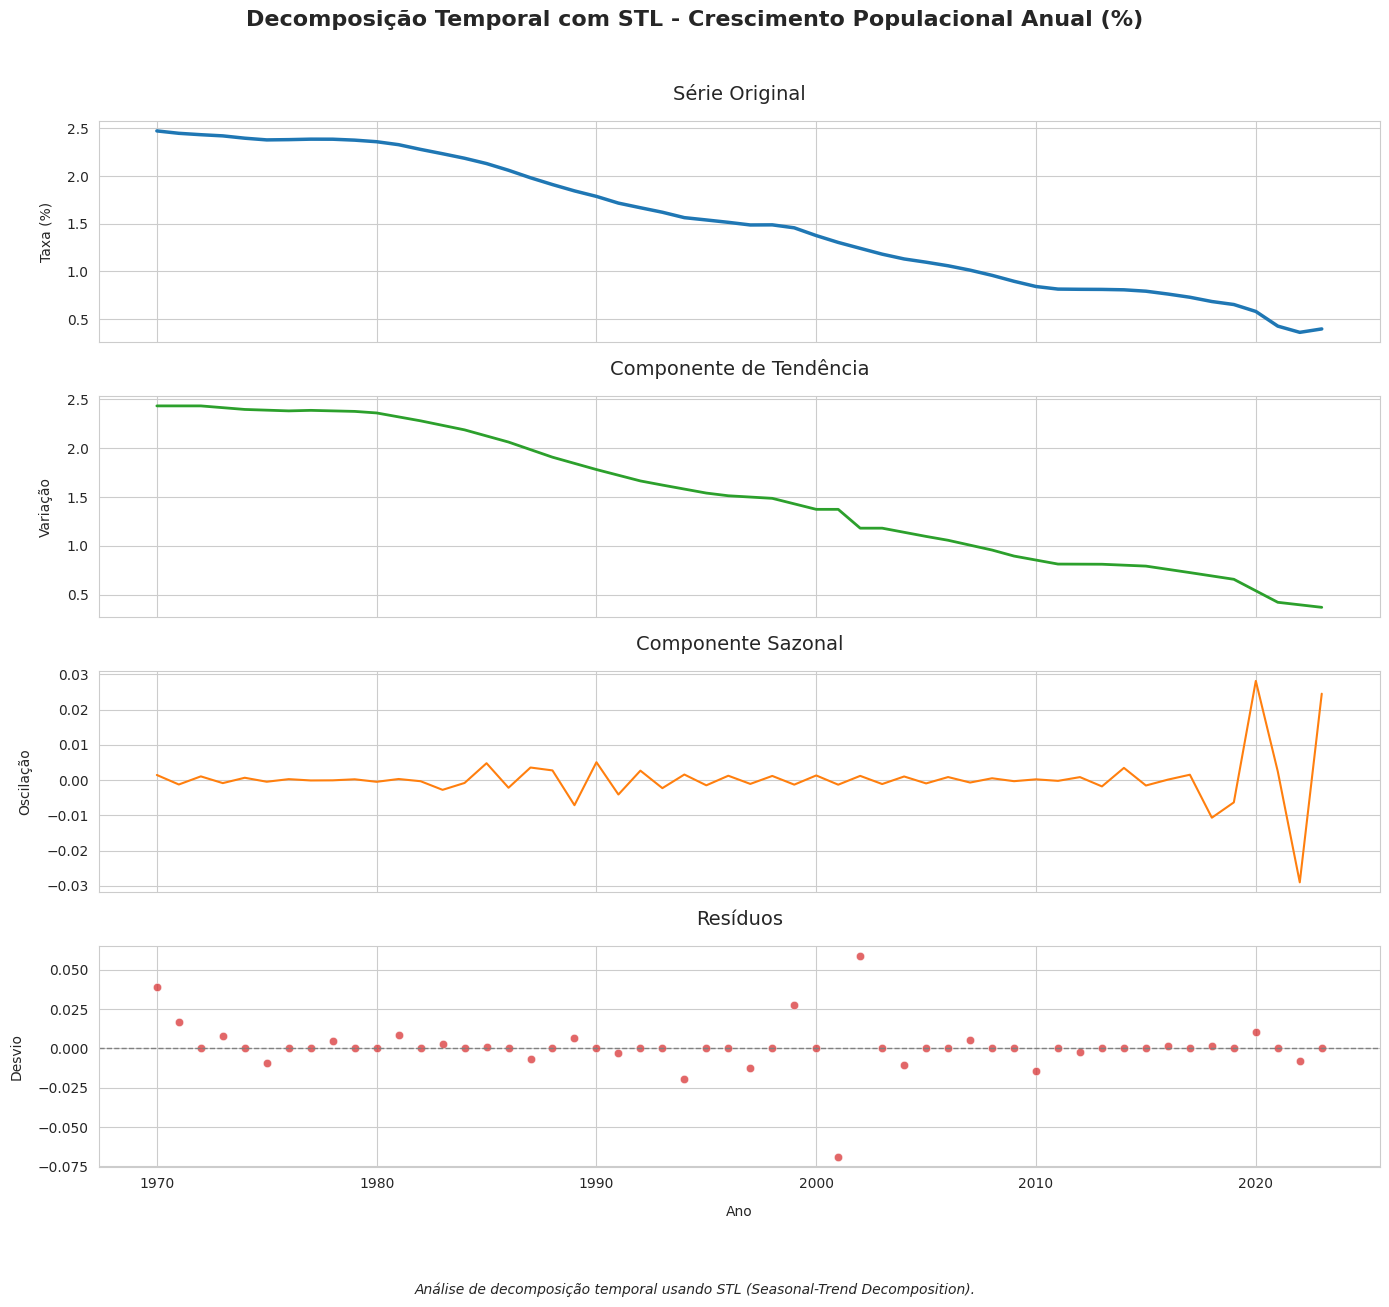

In [188]:
# Configuração de estilo mais robusta
plt.style.use('default')  # Usa o estilo padrão como base
sns.set_style("whitegrid")  # Estilo do seaborn
sns.set_palette("husl")  # Paleta de cores
plt.rcParams['figure.facecolor'] = 'white'  # Fundo branco

# Interpolação
pop_growth = new_df_brasil_wide['Population growth (annual %)'].interpolate()

# Verifica se há dados suficientes
if len(pop_growth) >= 4:
    # STL: usa o Loess para detectar tendência e sazonalidade
    stl = STL(pop_growth, period=2, robust=True)
    res = stl.fit()
    
    # Criar figura
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    fig.suptitle('Decomposição Temporal com STL - Crescimento Populacional Anual (%)', 
                 y=1.02, fontsize=16, fontweight='bold')
    
    # Série original
    sns.lineplot(x=pop_growth.index, y=pop_growth, ax=axes[0], linewidth=2.5, color='#1f77b4')
    axes[0].set_title('Série Original', pad=15, fontsize=14)
    axes[0].set_ylabel('Taxa (%)', labelpad=10)
    
    # Tendência
    sns.lineplot(x=res.trend.index, y=res.trend, ax=axes[1], linewidth=2, color='#2ca02c')
    axes[1].set_title('Componente de Tendência', pad=15, fontsize=14)
    axes[1].set_ylabel('Variação', labelpad=10)
    
    # Sazonalidade
    sns.lineplot(x=res.seasonal.index, y=res.seasonal, ax=axes[2], linewidth=1.5, color='#ff7f0e')
    axes[2].set_title('Componente Sazonal', pad=15, fontsize=14)
    axes[2].set_ylabel('Oscilação', labelpad=10)
    
    # Resíduos
    sns.scatterplot(x=res.resid.index, y=res.resid, ax=axes[3], color='#d62728', alpha=0.7)
    axes[3].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[3].set_title('Resíduos', pad=15, fontsize=14)
    axes[3].set_ylabel('Desvio', labelpad=10)
    axes[3].set_xlabel('Ano', labelpad=10)
    
    # Ajuste layout
    plt.tight_layout()
    plt.figtext(0.5, -0.05, 
                "Análise de decomposição temporal usando STL (Seasonal-Trend Decomposition).",
                ha="center", fontsize=10, style='italic')
    
    plt.show()

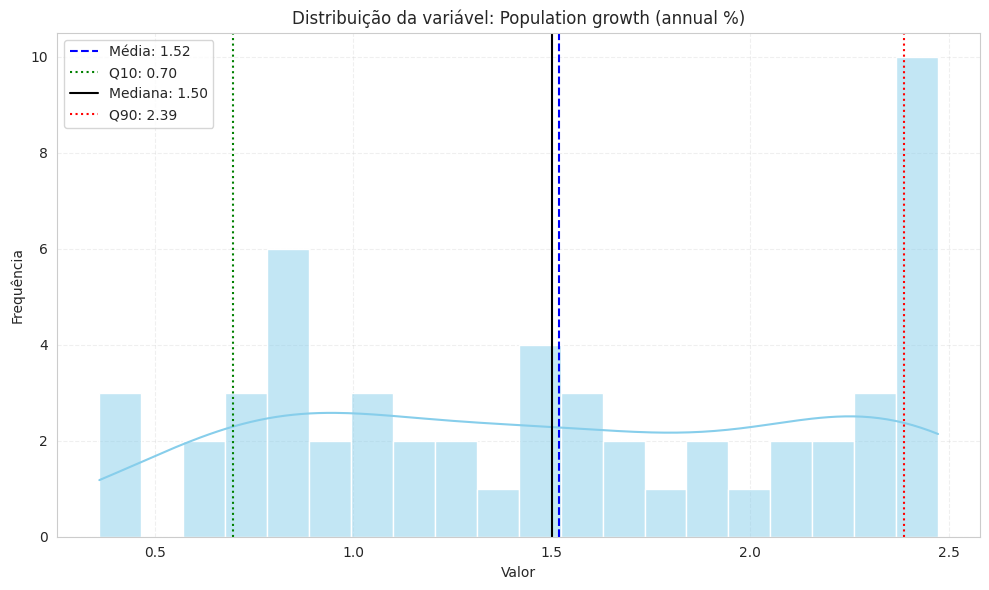

In [189]:
# Seleciona a variável
variavel = 'Population growth (annual %)'
serie = new_df_brasil_wide[variavel].dropna()

# Calcula estatísticas
media = serie.mean()
q10, mediana, q90 = np.percentile(serie, [10, 50, 90])
min_val, max_val = serie.min(), serie.max()

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(serie, kde=True, color='skyblue', bins=20)
plt.axvline(media, color='blue', linestyle='--', label=f'Média: {media:.2f}')
plt.axvline(q10, color='green', linestyle=':', label=f'Q10: {q10:.2f}')
plt.axvline(mediana, color='black', linestyle='-', label=f'Mediana: {mediana:.2f}')
plt.axvline(q90, color='red', linestyle=':', label=f'Q90: {q90:.2f}')
plt.title(f'Distribuição da variável: {variavel}')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


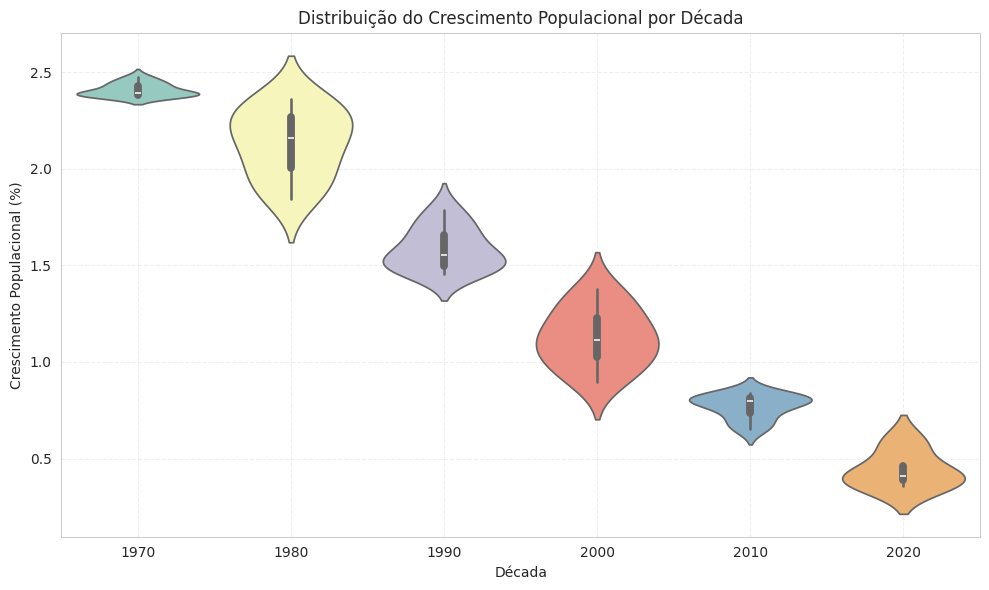

In [190]:
# Criar coluna de década
df_decada = new_df_brasil_wide.copy()
df_decada['Década'] = (df_decada.index // 10) * 10

# Plot para uma variável de interesse
plt.figure(figsize=(10, 6))
sns.violinplot(x='Década', y='Population growth (annual %)', data=df_decada.reset_index(), palette="Set3")
plt.title('Distribuição do Crescimento Populacional por Década')
plt.xlabel('Década')
plt.ylabel('Crescimento Populacional (%)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## Correlações

Phik por item

interval columns not set, guessing: ['Adjusted net national income (annual % growth)', 'Adjusted net national income (constant 2015 US$)', 'Adjusted savings: education expenditure (% of GNI)', 'Adjusted savings: energy depletion (% of GNI)', 'Adjusted savings: gross savings (% of GNI)', 'Adjusted savings: mineral depletion (% of GNI)', 'Adjusted savings: net national savings (% of GNI)', 'Adjusted savings: net national savings (current US$)', 'Adolescent fertility rate (births per 1,000 women ages 15-19)', 'Agricultural land (% of land area)', 'Agricultural raw materials exports (% of merchandise exports)', 'Agricultural raw materials imports (% of merchandise imports)', 'Agriculture, forestry, and fishing, value added (annual % growth)', 'Arable land (hectares per person)', 'Arms exports (SIPRI trend indicator values)', 'Arms imports (SIPRI trend indicator values)', 'Average precipitation in depth (mm per year)', 'Broad money (% of GDP)', 'Broad money growth (annual %)', 'Broad money 

Traceback (most recent call last):
  File "/home/pedro/Documentos/025.1/SME0852/.venv/lib/python3.12/site-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_comm.py", line 422, in _on_run
    cmd.send(self.sock)
  File "/home/pedro/Documentos/025.1/SME0852/.venv/lib/python3.12/site-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_net_command.py", line 111, in send
    sock.sendall(("Content-Length: %s\r\n\r\n" % len(as_bytes)).encode("ascii"))
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/pedro/Documentos/025.1/SME0852/.venv/lib/python3.12/site-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_daemon_thread.py", line 53, in run
    self._on_run()
  File "/home/pedro/Documentos/025.1/SME0852/.venv/lib/python3.12/site-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_comm.py", line 432, in _on_run
    self.py_db.dispose_and_kill_all_pydevd_threads()
  Fi

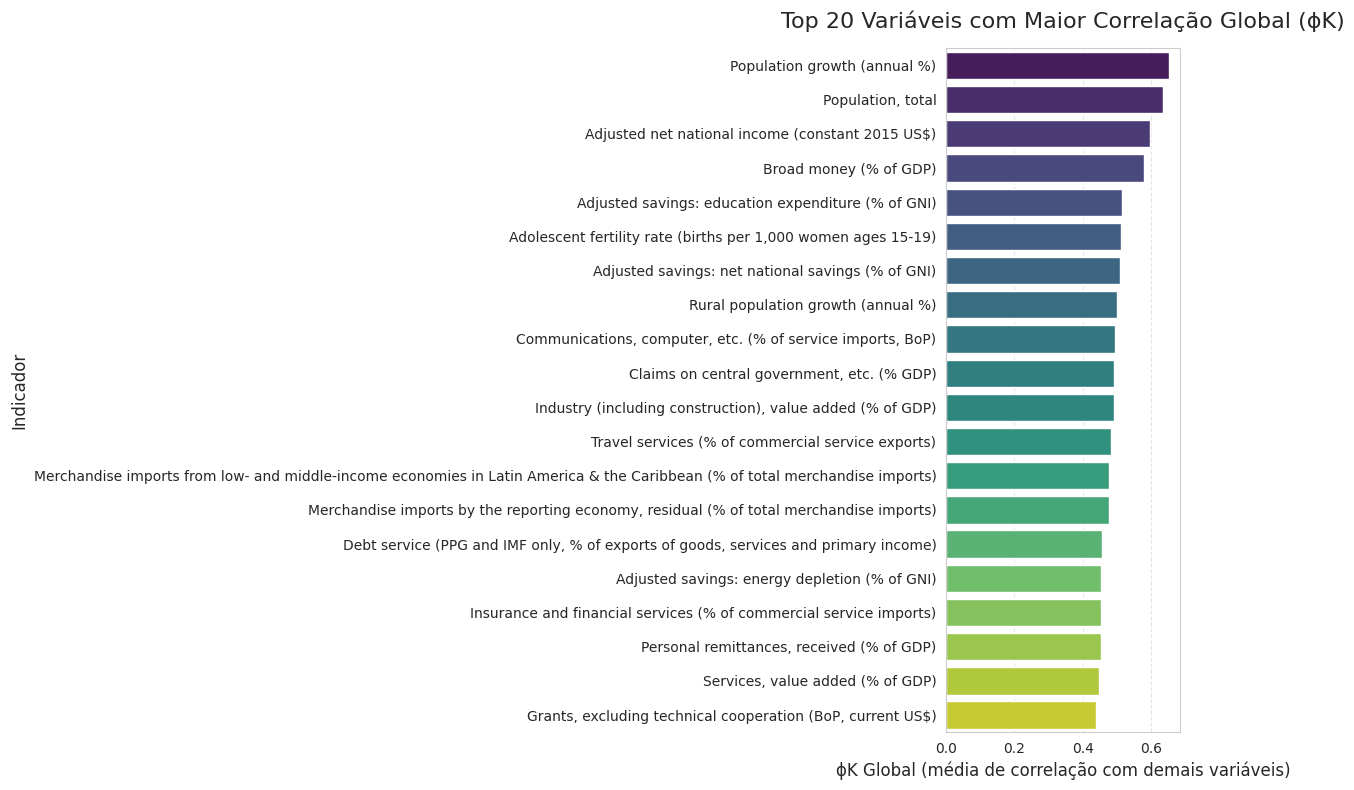

In [191]:
# Passo 1: interpolar valores faltantes
df_interp = new_df_brasil_wide.interpolate(method='linear', limit_direction='both')

# Passo 2: calcular matriz phik
phik_corr = df_interp.phik_matrix()

# Passo 3: calcular o vetor de correlação global (ϕK global)
phik_global = phik_corr.dropna(axis=0, how='all').mean(axis=1).sort_values(ascending=False)

# Passo 4: plotar o gráfico
plt.figure(figsize=(12, 8))
sns.barplot(y=phik_global.index[:20], x=phik_global.values[:20], palette='viridis')
plt.title('Top 20 Variáveis com Maior Correlação Global (ϕK)', fontsize=16, pad=15)
plt.xlabel('ϕK Global (média de correlação com demais variáveis)', fontsize=12)
plt.ylabel('Indicador', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

phik por macro tema

interval columns not set, guessing: ['Foreign direct investment, net outflows (% of GDP)', 'Net errors and omissions (BoP, current US$)', 'Reserves and related items (BoP, current US$)', 'Foreign direct investment, net inflows (% of GDP)', 'Portfolio equity, net inflows (BoP, current US$)', 'Current account balance (BoP, current US$)', 'Current account balance (% of GDP)', 'Net trade in goods (BoP, current US$)', 'Communications, computer, etc. (% of service imports, BoP)', 'Net secondary income (BoP, current US$)', 'Personal remittances, received (% of GDP)', 'Grants, excluding technical cooperation (BoP, current US$)', 'External debt stocks (% of GNI)', 'Short-term debt (% of total reserves)', 'Short-term debt (% of exports of goods, services and primary income)', 'Short-term debt (% of total external debt)', 'Total debt service (% of exports of goods, services and primary income)', 'Total debt service (% of GNI)', 'Public and publicly guaranteed debt service (% of GNI)', 'Multilater

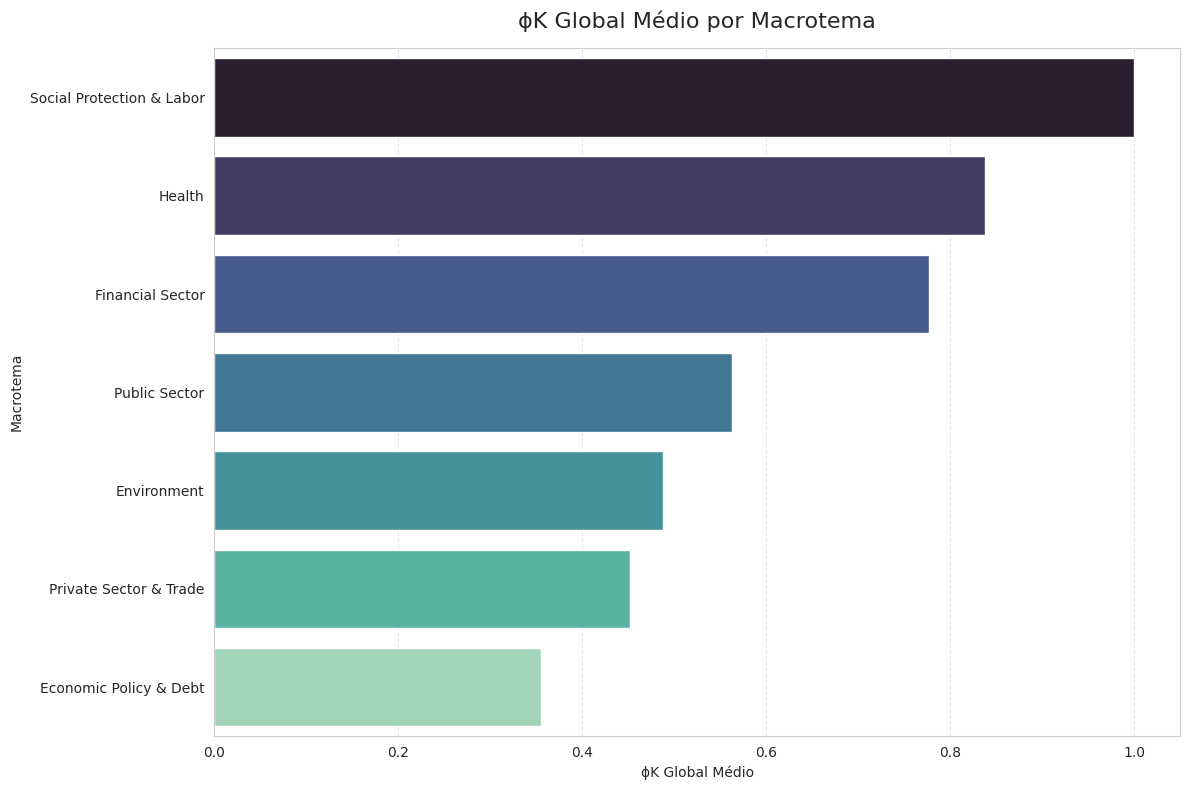

In [192]:
# Armazenar resultados
phik_macrotemas = {}

for tema, df in dfs_macrotema_unificado.items():
    # Interpola para preencher valores ausentes
    df_interp = df.interpolate(method='linear', limit_direction='both')

    try:
        # Calcula a matriz de correlação ϕK
        phik_corr = df_interp.phik_matrix()

        # Calcula o ϕK global (média das correlações de cada variável com as outras)
        phik_global_medio = phik_corr.dropna(axis=0, how='all').mean().mean()
        phik_macrotemas[tema] = phik_global_medio

    except Exception as e:
        print(f"Erro no macrotema '{tema}': {e}")

# Converter para DataFrame
phik_df = pd.DataFrame.from_dict(phik_macrotemas, orient='index', columns=['ϕK Global Médio'])
phik_df.sort_values('ϕK Global Médio', ascending=False, inplace=True)

# Plotar gráfico
plt.figure(figsize=(12, 8))
sns.barplot(x=phik_df['ϕK Global Médio'], y=phik_df.index, palette='mako')
plt.title('ϕK Global Médio por Macrotema', fontsize=16, pad=15)
plt.xlabel('ϕK Global Médio')
plt.ylabel('Macrotema')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Pear por itens

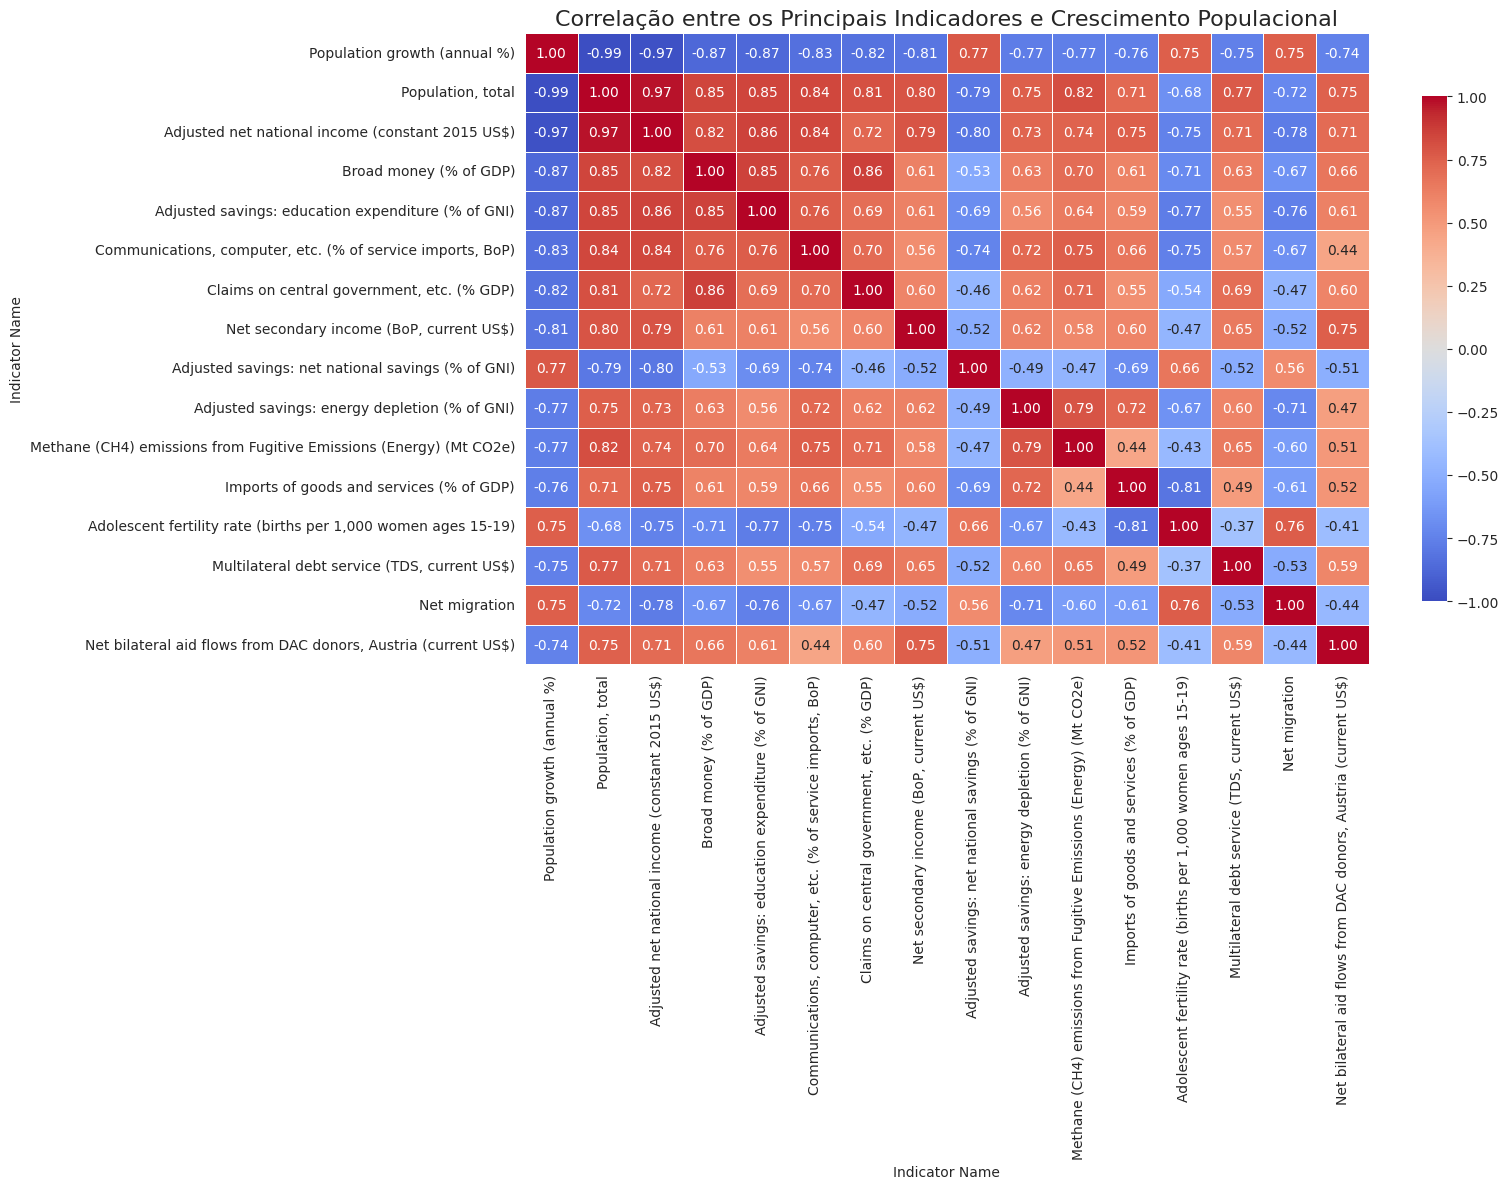

In [193]:
# 1. Análise de Correlação Avançada
plt.figure(figsize=(16, 12))
# Selecionando os 15 indicadores mais correlacionados com crescimento populacional
corr_pop = new_df_brasil_wide.corr()['Population growth (annual %)'].abs().sort_values(ascending=False)
top_15_vars = corr_pop.head(16).index
corr_matrix = new_df_brasil_wide[top_15_vars].corr()

# Máscara para triângulo superior
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt='.2f', linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlação entre os Principais Indicadores e Crescimento Populacional', fontsize=16)
plt.tight_layout()
plt.show()

pearson por macro

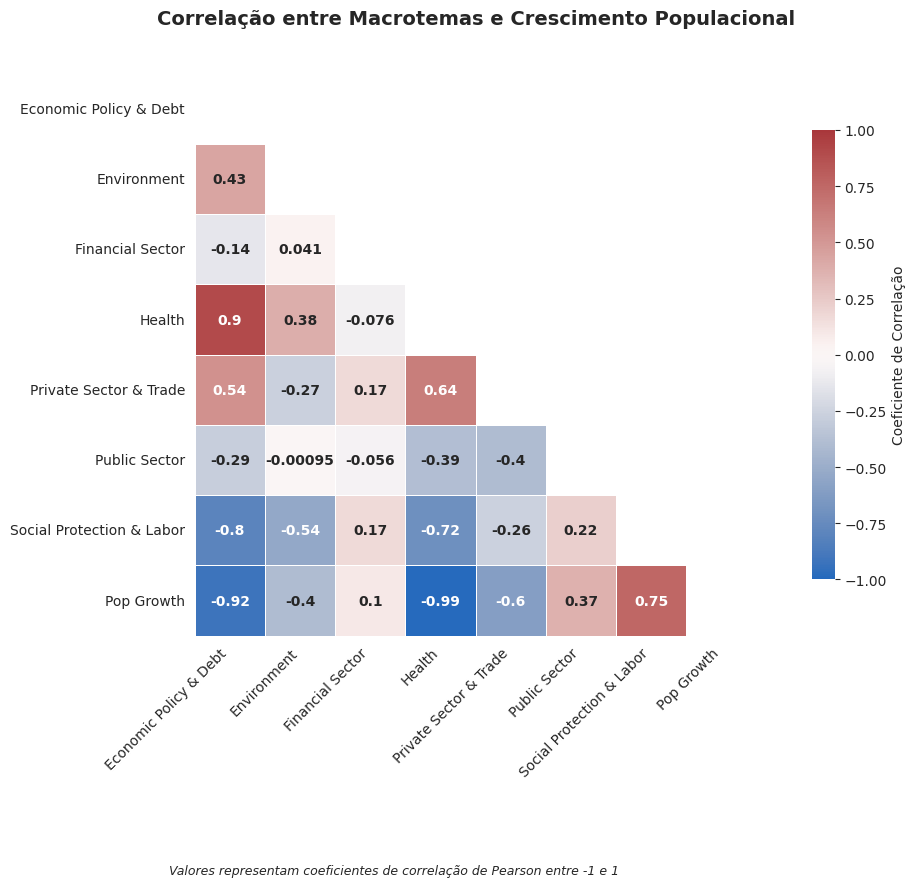

In [194]:
medias_macro = {}
for macrotema, df_macro in dfs_macrotema_unificado.items():
    df_macro_interp = df_macro.interpolate(method='linear', limit_direction='both')
    medias_macro[macrotema] = df_macro_interp.mean(axis=1)

df_macro_medias = pd.DataFrame(medias_macro)
df_macro_medias['Pop Growth'] = new_df_brasil_wide['Population growth (annual %)']
# Configurações de estilo
plt.style.use('default')
sns.set_style("white")
plt.rcParams['figure.facecolor'] = 'white'

# Criar a figura
plt.figure(figsize=(12, 8))

# Gerar a máscara para o triângulo superior (opcional)
mask = np.triu(np.ones_like(df_macro_medias.corr(), dtype=bool))

# Heatmap aprimorado
heatmap = sns.heatmap(
    df_macro_medias.corr(),
    mask=mask,  # Remover se quiser mostrar toda a matriz
    annot=True,
    annot_kws={'size': 10, 'weight': 'bold'},
    cmap='vlag',  # Alternativa: 'coolwarm', 'RdBu_r', 'icefire'
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Correlação'}
)

# Melhorar título
plt.title(
    "Correlação entre Macrotemas e Crescimento Populacional\n",
    fontsize=14,
    pad=20,
    fontweight='bold'
)

# Rotacionar os rótulos do eixo x
heatmap.set_xticklabels(
    heatmap.get_xticklabels(),
    rotation=45,
    horizontalalignment='right',
    fontsize=10
)

# Ajustar rótulos do eixo y
heatmap.set_yticklabels(
    heatmap.get_yticklabels(),
    rotation=0,
    fontsize=10
)

# Adicionar grade de referência (opcional)
heatmap.grid(False)

# Ajustar layout
plt.tight_layout()

# Adicionar nota de rodapé
plt.figtext(
    0.5, -0.1,
    "Valores representam coeficientes de correlação de Pearson entre -1 e 1",
    ha="center",
    fontsize=9,
    style='italic'
)

plt.show()



## Pop Geral

In [195]:
fig = px.line(
    new_df_brasil_wide,
    x=new_df_brasil_wide.index,
    y='Population, total',
    title='População Total ao Longo dos Anos',
    labels={'Ano': 'Ano', 'Population': 'População (milhões de pessoas)'},
    markers=True
)

fig.update_layout(
    xaxis_title='Ano',
    yaxis_title='População (milhões de pessoas)', 
    legend_title_text='Legenda'
)

fig.show()

# Pré processamento

## Modelos

In [196]:
models = {
    "RandomForestRegressor": RandomForestRegressor(random_state=42),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42), 
    "LinearRegression" : LinearRegression(),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42),
    "SVR": SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "KNeighborsRegressor": KNeighborsRegressor(n_neighbors=5),
    "Lasso" : Lasso(alpha=0.01, random_state=42),
    "Ridge": Ridge(alpha=0.01, random_state=42)
}

In [197]:
forecaster = []
for i in models.keys():
   modelo = models[i]
   forecaster_ = ForecasterRecursive(
                  regressor = modelo,
                  lags = 9
               )
   forecaster.append(forecaster_)

## Tirando variaveis pouco correlacionadas com o target

### Através da correlação

In [198]:
# Preencher NaNs (por exemplo com interpolação linear)
df = new_df_brasil_wide.interpolate(method='linear', limit_direction='both')

# Padronizar os dados
df_zscore = df.apply(zscore)

# Função para calcular a correlação cruzada entre duas séries
def max_cross_corr(series1, series2, max_lag=5):
    lags = range(-max_lag, max_lag + 1)
    corrs = [series1.corr(series2.shift(lag)) for lag in lags]
    max_corr = max(corrs, key=abs)
    return max_corr

# Parâmetros
threshold = 0.7 
max_lag = 5

# Detectar pares altamente correlacionados com defasagem
to_remove = set()
columns = df_zscore.columns.tolist()

for i, col1 in enumerate(columns):
    for col2 in columns[i+1:]:
        corr = max_cross_corr(df_zscore['Population, total'], df_zscore[col2], max_lag=max_lag)
        if abs(corr) < threshold:
            to_remove.add(col2)

# Remover colunas redundantes
new_df_brasil_wide = df.drop(columns=to_remove)

print(f"\n{len(to_remove)} variáveis removidas por correlação cruzada.")


109 variáveis removidas por correlação cruzada.


In [199]:
# Informações gerais sobre nulos e dimensões
linhas, colunas = new_df_brasil_wide.shape
total_celulas = linhas * colunas
total_nulos = new_df_brasil_wide.isnull().sum().sum()
porcentagem_nulos = (total_nulos / total_celulas) * 100

print(f"Linhas: {linhas}")
print(f"Colunas: {colunas}")
print(f"Total de valores nulos: {total_nulos}")

Linhas: 54
Colunas: 25
Total de valores nulos: 0


### Rede Bayesiana

#### Discretizando as variaveis

In [200]:
df_qcut = new_df_brasil_wide.copy()
for col in df_qcut.columns:
    df_qcut[col] = pd.qcut(df_qcut[col], q=4, labels=[0, 1, 2, 3])
    df_qcut[col] = df_qcut[col].astype('category')


#### Estruturando rede

In [201]:
est = HillClimbSearch(data=df_qcut)
best_model = est.estimate(scoring_method=BIC(data=df_qcut), max_iter=24, show_progress=True)
model_structure = DiscreteBayesianNetwork(best_model.edges())

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Adjusted net national income (annual % growth)': 'O', 'Adjusted net national income (constant 2015 US$)': 'O', 'Adjusted savings: education expenditure (% of GNI)': 'O', 'Adjusted savings: energy depletion (% of GNI)': 'O', 'Adjusted savings: net national savings (% of GNI)': 'O', 'Adolescent fertility rate (births per 1,000 women ages 15-19)': 'O', 'Arable land (hectares per person)': 'O', 'Broad money (% of GDP)': 'O', 'Claims on central government, etc. (% GDP)': 'O', 'Communications, computer, etc. (% of service imports, BoP)': 'O', 'Exports of goods and services (% of GDP)': 'O', 'Foreign direct investment, net inflows (% of GDP)': 'O', 'Imports of goods and services (% of GDP)': 'O', 'Merchandise exports to low- and middle-income economies in Latin America & the Caribbean (% of total merchandise exports)': 'O', 'Merchandise imports by the reporting economy, residual (% of to

#### Gerando Tbalea de probabilidade

In [202]:
model_structure.fit(data=df_qcut, estimator=MaximumLikelihoodEstimator)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Adjusted net national income (annual % growth)': 'O', 'Adjusted net national income (constant 2015 US$)': 'O', 'Adjusted savings: education expenditure (% of GNI)': 'O', 'Adjusted savings: energy depletion (% of GNI)': 'O', 'Adjusted savings: net national savings (% of GNI)': 'O', 'Adolescent fertility rate (births per 1,000 women ages 15-19)': 'O', 'Arable land (hectares per person)': 'O', 'Broad money (% of GDP)': 'O', 'Claims on central government, etc. (% GDP)': 'O', 'Communications, computer, etc. (% of service imports, BoP)': 'O', 'Exports of goods and services (% of GDP)': 'O', 'Foreign direct investment, net inflows (% of GDP)': 'O', 'Imports of goods and services (% of GDP)': 'O', 'Merchandise exports to low- and middle-income economies in Latin America & the Caribbean (% of total merchandise exports)': 'O', 'Merchandise imports by the reporting economy, residual (% of to

In [203]:
print("\nModelo está consistente (todas as CPTs somam 1 para cada estado pai):", model_structure.check_model())


Modelo está consistente (todas as CPTs somam 1 para cada estado pai): True


#### Gerando Targett

In [204]:
target_node = 'Population, total'
parents_of_target = model_structure.get_parents(target_node)
print(f"\nIndicadores que são pais diretos de '{target_node}':")
print(parents_of_target)


Indicadores que são pais diretos de 'Population, total':
['Adjusted net national income (constant 2015 US$)']


#### Analisando Rede Bayesiana

In [205]:
infer = VariableElimination(model_structure)

# Exemplo 1: Qual a probabilidade de 'Population_total_cat' estar em 'Alto' (ou 2),
# dado que um dos seus pais diretos está em 'Alto' (ou 2)?
# Suponha que 'Ind_X_cat' é um dos pais que você identificou
if parents_of_target:
    first_parent = parents_of_target[0] # Pegue o primeiro pai como exemplo

    # Exemplo: Probabilidade de População Alta dado que o primeiro pai é Alto (2)
    # Assumindo que 2 é o estado de 'alto' para as variáveis discretizadas
    # (Ajuste os valores de 'evidence' conforme seus labels de discretização)
    prob_pop_given_parent = infer.query(variables=[target_node], evidence={first_parent: 2})
    print(f"\nProbabilidade de '{target_node}' dado que '{first_parent}' é 'alto' (estado 2):")
    print(prob_pop_given_parent)

    prob_pop_given_parent_med = infer.query(variables=[target_node], evidence={first_parent: 1})
    print(f"\nProbabilidade de '{target_node}' dado que '{first_parent}' é 'baixo' (estado 1):")
    print(prob_pop_given_parent_med)

    # Exemplo: Probabilidade de População Baixa dado que o primeiro pai é Baixo (0)
    prob_pop_given_parent_low = infer.query(variables=[target_node], evidence={first_parent: 0})
    print(f"\nProbabilidade de '{target_node}' dado que '{first_parent}' é 'médio' (estado 0):")
    print(prob_pop_given_parent_low)


    # Compare com a probabilidade marginal (sem evidência)
    prob_pop_marginal = infer.query(variables=[target_node])
    print(f"\nProbabilidade marginal de '{target_node}':")
    print(prob_pop_marginal)

else:
    print("\nNão foram encontrados pais diretos para a variável alvo, o que é incomum se há correlação.")
    print("Revise seus dados, discretização, ou o algoritmo de aprendizado de estrutura.")


Probabilidade de 'Population, total' dado que 'Adjusted net national income (constant 2015 US$)' é 'alto' (estado 2):
+----------------------+--------------------------+
| Population, total    |   phi(Population, total) |
+======================+==========================+
| Population, total(0) |                   0.0000 |
+----------------------+--------------------------+
| Population, total(1) |                   0.0769 |
+----------------------+--------------------------+
| Population, total(2) |                   0.9231 |
+----------------------+--------------------------+
| Population, total(3) |                   0.0000 |
+----------------------+--------------------------+

Probabilidade de 'Population, total' dado que 'Adjusted net national income (constant 2015 US$)' é 'baixo' (estado 1):
+----------------------+--------------------------+
| Population, total    |   phi(Population, total) |
+======================+==========================+
| Population, total(0) |         

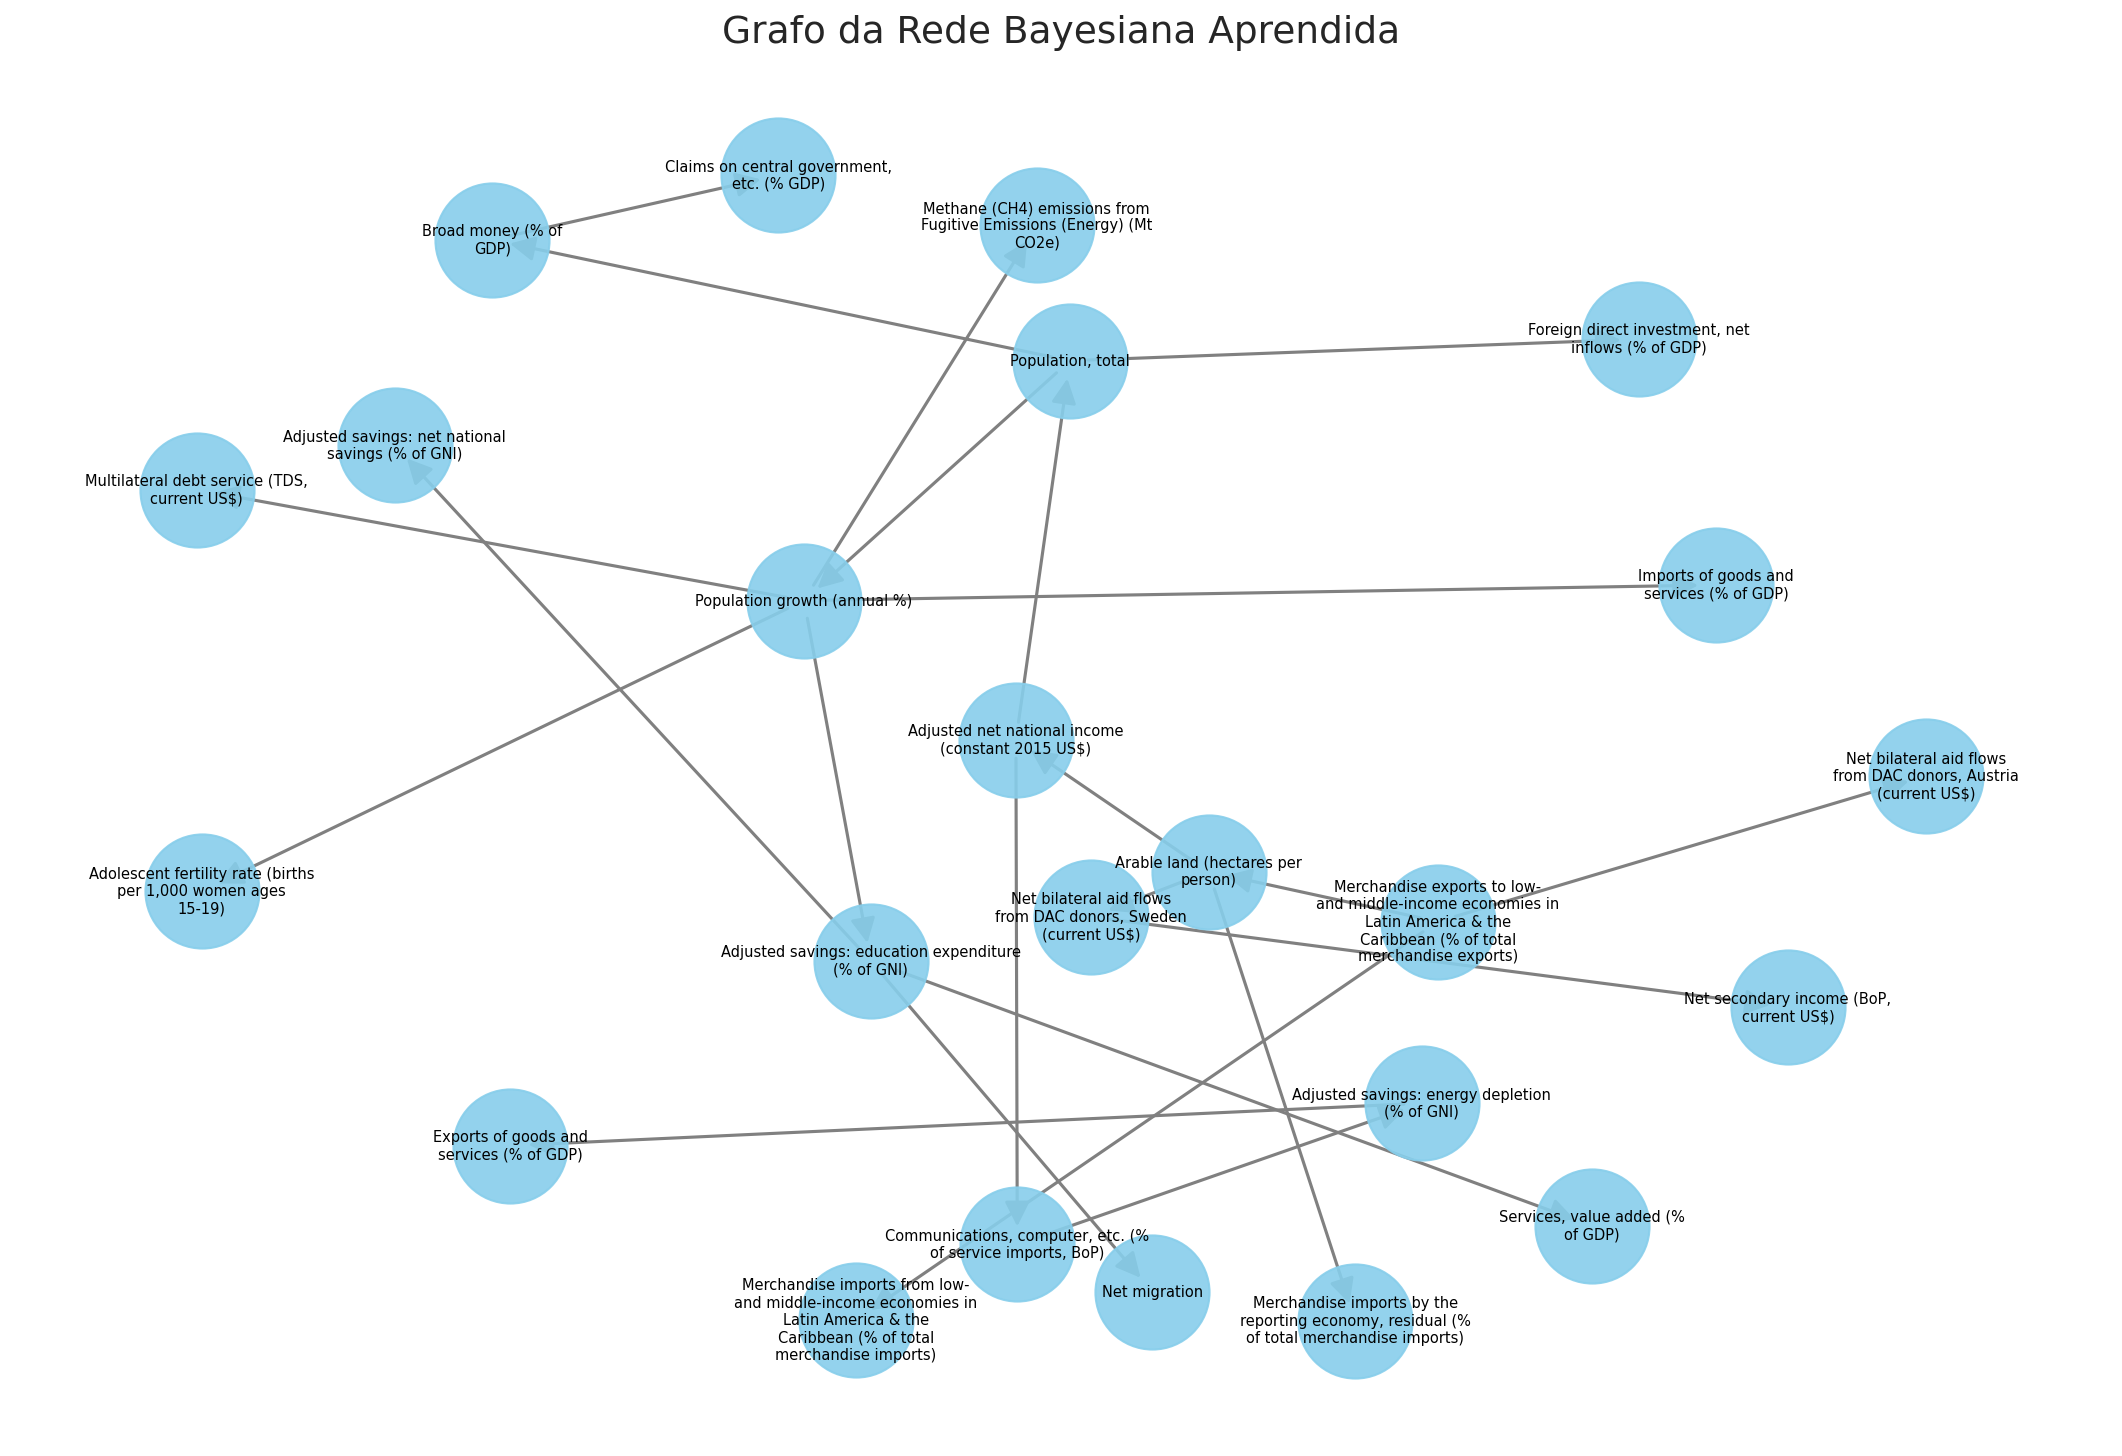

In [215]:

# Converta para um DiGraph do NetworkX
nx_graph = nx.DiGraph(model_structure.edges())

# Desenhe com networkx
plt.figure(figsize=(18, 12), dpi=150)
pos = nx.spring_layout(nx_graph, seed=42, k=0.9)

nx.draw_networkx_nodes(nx_graph, pos, node_size=3000, node_color="skyblue", alpha=0.9)
nx.draw_networkx_edges(nx_graph, pos, arrows=True, arrowsize=25, edge_color="gray", width=1.5)
def wrap_label(label, max_words=5):
    words = label.split()
    return "\n".join([" ".join(words[i:i + max_words]) for i in range(0, len(words), max_words)])

# Aplica isso nos rótulos:
labels = {node: wrap_label(node, max_words=4) for node in nx_graph.nodes()}
nx.draw_networkx_labels(nx_graph, pos, labels=labels, font_size=7)
 # ou nx.circular_layout, nx.shell_layout


plt.title("Grafo da Rede Bayesiana Aprendida", size=18)
plt.axis("off")
plt.show()

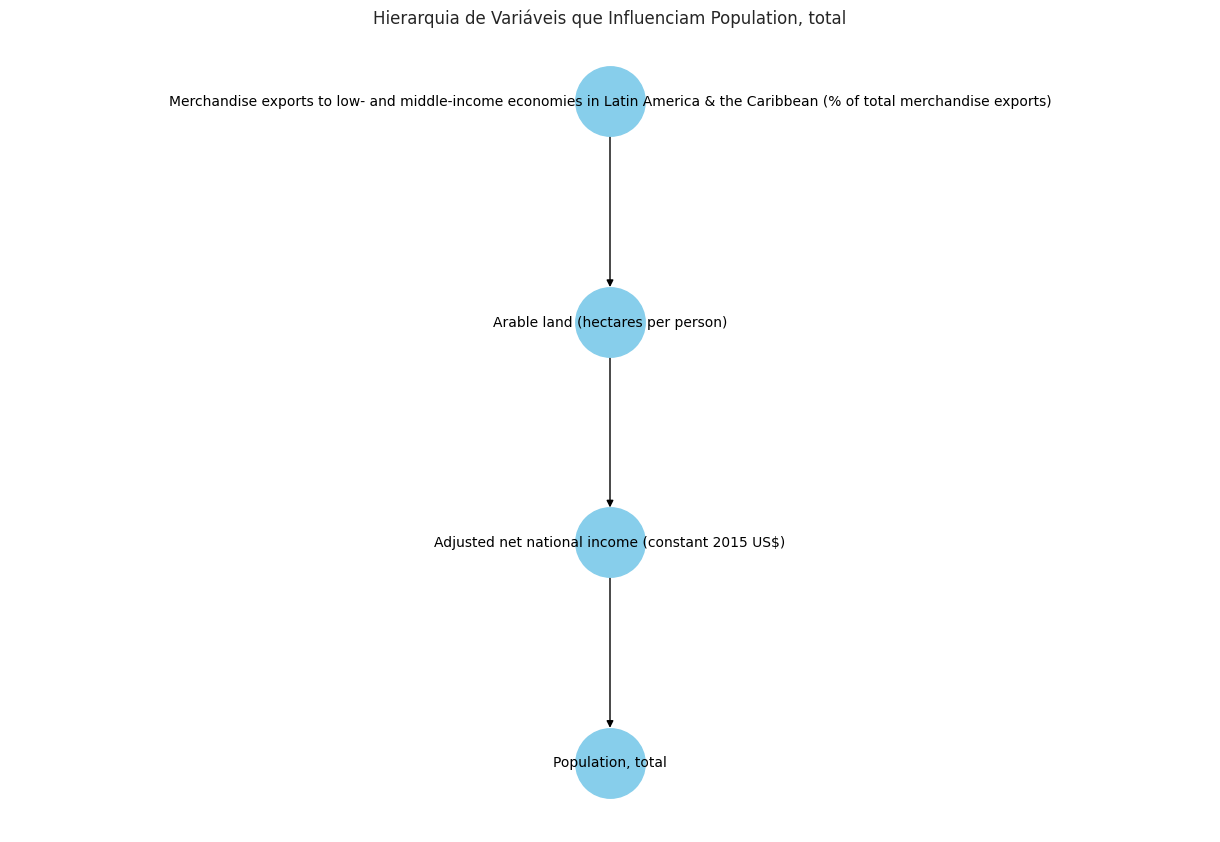

In [219]:
def get_ancestors(model, target_node):
    ancestors = set()
    stack = [target_node]
    while stack:
        node = stack.pop()
        parents = model.get_parents(node)
        for parent in parents:
            if parent not in ancestors:
                ancestors.add(parent)
                stack.append(parent)
    return ancestors


target = "Population, total"
ancestors = get_ancestors(model_structure, target)
relevant_nodes = ancestors.union({target})

# Subgrafo com apenas os nós relevantes
subgraph_edges = [(u, v) for u, v in model_structure.edges() if u in relevant_nodes and v in relevant_nodes]
sub_model = DiscreteBayesianNetwork(subgraph_edges)

G = nx.DiGraph()
G.add_edges_from(sub_model.edges())

# Layout hierárquico: root node como 'Population, total'
pos = nx.nx_agraph.graphviz_layout(G, prog="dot")  # usa Graphviz: precisa de instalação

plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color="skyblue", node_size=2500, font_size=10, arrows=True)
plt.title("Hierarquia de Variáveis que Influenciam Population, total")
plt.show()

## Criando variavel "defasada"

In [ ]:
df_to_predict = new_df_brasil_wide.copy()

In [ ]:
df_to_predict['Populacao_Anterior'] = df_to_predict['Population, total'].shift(1).fillna(method='bfill')
df_to_predict['Populacao_Anterior'].info()

<class 'pandas.core.series.Series'>
Index: 54 entries, 1970 to 2023
Series name: Populacao_Anterior
Non-Null Count  Dtype  
--------------  -----  
54 non-null     float64
dtypes: float64(1)
memory usage: 864.0 bytes


## Para Modelos de Regressão

### Criando teste e treino

#### Pelo DataFrame

In [ ]:
target = 'Population, total'
features = df_to_predict.drop(columns=[target, 'Population, total']).columns.tolist()

In [ ]:
X = df_to_predict[features]
y = df_to_predict[target]

In [ ]:
# Encontra o índice que divide os dados em 80/20
split_index = int(len(df_to_predict) * 0.8)

# Divide o DataFrame
treino_df = df_to_predict.iloc[:split_index]
teste_df = df_to_predict.iloc[split_index:]

# Cria os conjuntos de treino e teste
X_treino = treino_df[features]
y_treino = treino_df[target]

X_teste = teste_df[features]
y_teste = teste_df[target]

## Para o Modelo de Forecast

###

In [ ]:
df_forecast = df_to_predict.copy()
df_forecast.index = pd.to_datetime(df_forecast.index, format='%Y')
df_forecast = df_forecast.asfreq('YS')

### Definindo variavel Target

In [ ]:
populacao_total = df_forecast['Population, total'].dropna()

### Definindo "features"

In [ ]:
X_exogenas = df_forecast.drop(columns='Population, total')
X_exogenas = X_exogenas.reindex(populacao_total.index)
X_exogenas = X_exogenas.interpolate(method='linear', limit_direction='both')
X_exogenas = X_exogenas.drop(columns=['Population growth (annual %)'])

### Criando treino e teste

In [ ]:
variaveis = {}
for i in forecaster:
    lista = []
    X_train_cast, y_train_cast = i.create_train_X_y(
                        y    = populacao_total,
                        exog = X_exogenas
                    )
    lista.append(X_train_cast)
    lista.append(y_train_cast)
    variaveis[i.regressor.__class__.__name__] = lista


# Modelagem

## Treinamento Com Regressão

In [ ]:
resultos = {}

for name, model in models.items():
    # Treinar o modelo
    model.fit(X_treino, y_treino)
    
    y_pred = model.predict(X_teste)
    r2 = r2_score(y_teste, y_pred)
    rmse = np.sqrt(mean_squared_error(y_teste, y_pred))
    mape = mean_absolute_percentage_error(y_teste, y_pred)
    
    resultos[name] = {'R²': r2, 'RMSE': rmse, 'MAPE': mape, 'Modelo': name}

## Treino para Com Backtesting

In [ ]:
cv = TimeSeriesFold(steps= int(10), initial_train_size = int(24))
metricas = pd.DataFrame(columns=['Modelo'])
lista_de_metricas = []
lista_previsoes_backtesting = {}

for i in forecaster :
  nome_modelo = i.regressor.__class__.__name__
  metrica, previsoes_backtesting = backtesting_forecaster(
                                      forecaster         = i,
                                      y                  = variaveis[nome_modelo][1],
                                      exog              = variaveis[nome_modelo][0],
                                      metric             = [mean_squared_error, r2_score, 'mean_absolute_percentage_error'],
                                      cv               = cv,
                                      return_predictors = True
                                    )
  metrica['Modelo'] = nome_modelo
  lista_de_metricas.append(metrica)
  lista_previsoes_backtesting[nome_modelo]= previsoes_backtesting


metricas = pd.concat(lista_de_metricas, ignore_index=True)
metricas['mean_squared_error'] = np.sqrt(metricas['mean_squared_error'])
metricas = metricas.rename(columns={
      'r2_score': 'R²',
      'mean_squared_error': 'RMSE',
      'mean_absolute_percentage_error': 'MAPE'
  })
metricas_com_variaveis = metricas.set_index('Modelo').sort_values(by='R²', ascending=False)

100%|██████████| 3/3 [00:00<00:00, 405.53it/s]


## Curva de Crescimento

### Defindo função de crescimento:

In [ ]:
def richards_curve(t, K, B, M, v, A=0):
    return K / (1 + np.exp(-B * (t - M)))**(1/v)

media_anos = int(sum(df_to_predict.index)/len(df_to_predict.index))

In [ ]:
initial_A = df_to_predict['Population, total'].max() * 1.1
initial_R = 0.05
initial_M = media_anos
initial_v = 1.0
bounds = (
    [df_to_predict['Population, total'].max(), 0.001, df_to_predict.index.min(), 0.01],  # Limites inferiores
    [df_to_predict['Population, total'].max() * 2, 1.0, df_to_predict.index.max(), 5.0]  # Limites superiores (ajuste conforme necessário)
)

p0 = [initial_A, initial_R, initial_M, initial_v]


### Pegando  melhores parametros

In [ ]:
popt, pcov = curve_fit(richards_curve, df_to_predict.index, df_to_predict['Population, total'], p0=p0, bounds=bounds, maxfev=5000)
A_fit, B_fit, M_fit, v_fit = popt

print("--- Resultados do Ajuste do Modelo de Richards ---")
print(f"Parâmetros Ótimos: A={A_fit:.2f}, B={B_fit:.4f}, M={M_fit:.2f}, v={v_fit:.2f}")

--- Resultados do Ajuste do Modelo de Richards ---
Parâmetros Ótimos: A=231391056.28, B=0.0579, M=1991.81, v=1.69


# Resultados

## Regressão

In [ ]:
resultos_df = pd.DataFrame(resultos).T
resultos_df = resultos_df.sort_values(by='R²', ascending=False).set_index('Modelo')

print("--- Tabela Comparativa de Resultados ---")
resultos_df.head()

--- Tabela Comparativa de Resultados ---


,R²,RMSE,MAPE
Modelo,,,
LinearRegression,0.79,1885482.26,0.01
Ridge,0.77,1967882.69,0.01
ElasticNet,0.17,3722529.65,0.02
Lasso,-2.27,7408096.57,0.03
KNeighborsRegressor,-8.62,12701246.84,0.06


## Forecast

In [ ]:
metricas_com_variaveis = metricas_com_variaveis[['R²', 'RMSE', 'MAPE']]
metricas_com_variaveis

,R²,RMSE,MAPE
Modelo,,,
Ridge,1.00,359555.14,0.00
LinearRegression,1.00,361739.07,0.00
ElasticNet,1.00,470672.54,0.00
Lasso,0.97,1534920.25,0.01
GradientBoostingRegressor,-6.01,24973284.72,0.11
RandomForestRegressor,-6.35,25573909.75,0.12
KNeighborsRegressor,-6.93,26558337.81,0.12
SVR,-14.59,37235369.25,0.18


## Modelos Melhor performaram

In [ ]:
modelos_anaisar = ['LinearRegression','ElasticNet', 'Ridge']

## Impacto de cada feature

In [ ]:
forecasters_dict = {f.regressor.__class__.__name__: f for f in forecaster}
feature_importances = {}

for nome_do_modelo in modelos_anaisar:
    print(f"--- Feature Importances for {nome_do_modelo} ---")
    
    forecaster_obj = forecasters_dict.get(nome_do_modelo)
    
    if forecaster_obj:

        y_treino_final = variaveis[nome_do_modelo][1]
        X_treino_final = variaveis[nome_do_modelo][0]
        forecaster_obj.fit(y=y_treino_final, exog=X_treino_final)
        importances = forecaster_obj.get_feature_importances()
        feature_importances[nome_do_modelo] = importances
        print(importances)
        print("\n" + "="*50 + "\n")
    
    else:
        print(f"Model '{nome_do_modelo}' not found.")

--- Feature Importances for LinearRegression ---
                                              feature  importance
34  Methane (CH4) emissions from Fugitive Emission...    12016.75
33  Merchandise imports from low- and middle-incom...     8782.60
23  Adolescent fertility rate (births per 1,000 wo...     6063.95
30           Imports of goods and services (% of GDP)     3636.70
28           Exports of goods and services (% of GDP)     3546.50
40                   Services, value added (% of GDP)     3028.28
18     Adjusted net national income (annual % growth)     1650.13
41                                 Populacao_Anterior        1.88
9                                               lag_1        1.88
11                                              lag_3        1.21
2                                               lag_3        1.19
6                                               lag_7        0.87
15                                              lag_7        0.87
13                         

In [ ]:
df_faeture_importances = pd.concat(feature_importances)
df_faeture_importances

feature  \
LinearRegression 34  Methane (CH4) emissions from Fugitive Emission...   
                 33  Merchandise imports from low- and middle-incom...   
                 23  Adolescent fertility rate (births per 1,000 wo...   
                 30           Imports of goods and services (% of GDP)   
                 28           Exports of goods and services (% of GDP)   
...                                                                ...   
Ridge            12                                              lag_4   
                 15                                              lag_7   
                 6                                               lag_7   
                 1                                               lag_2   
                 10                                              lag_2   

                     importance  
LinearRegression 34    12016.75  
                 33     8782.60  
                 23     6063.95  
                 30     3636.70  
                 28     3546.50  
...                         ...  
Ridge            12       -0.57  
                 15       -0.62  
                 6        -0.62  
                 1        -1.18  
                 10       -1.18  

[126 rows x 2 columns]

# Validação do Melhores Modelos

## Analise dos residuos

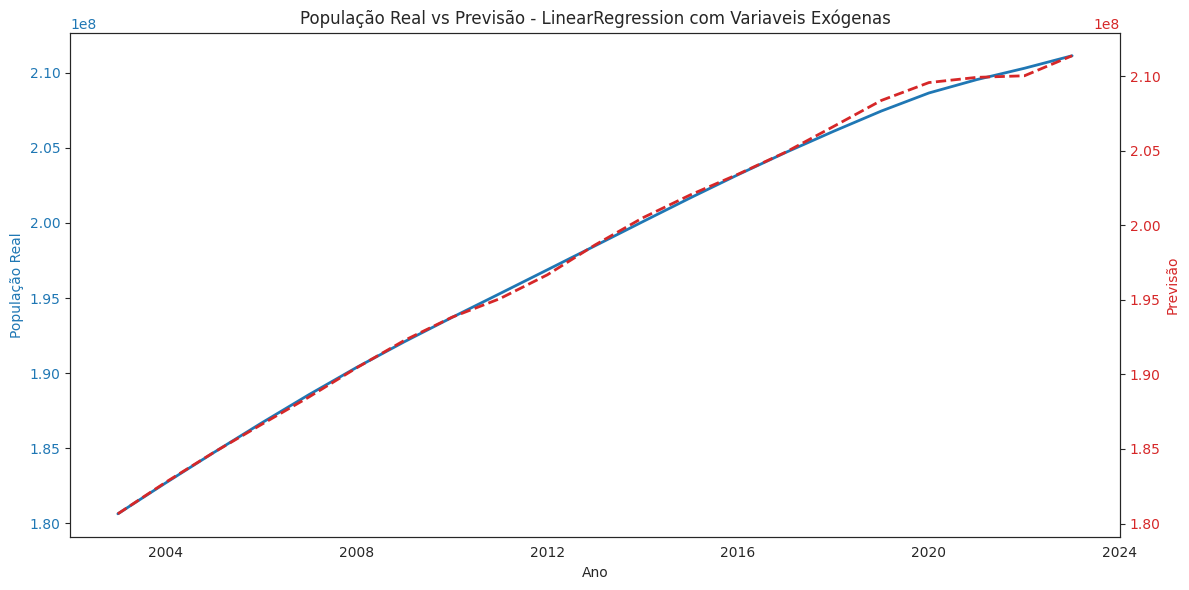

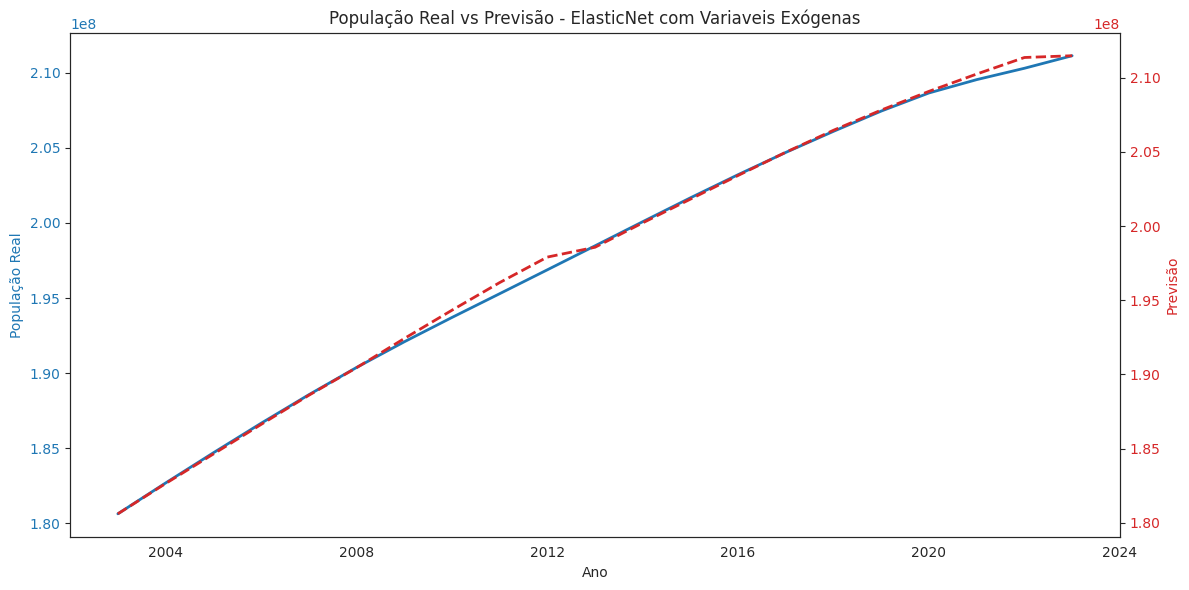

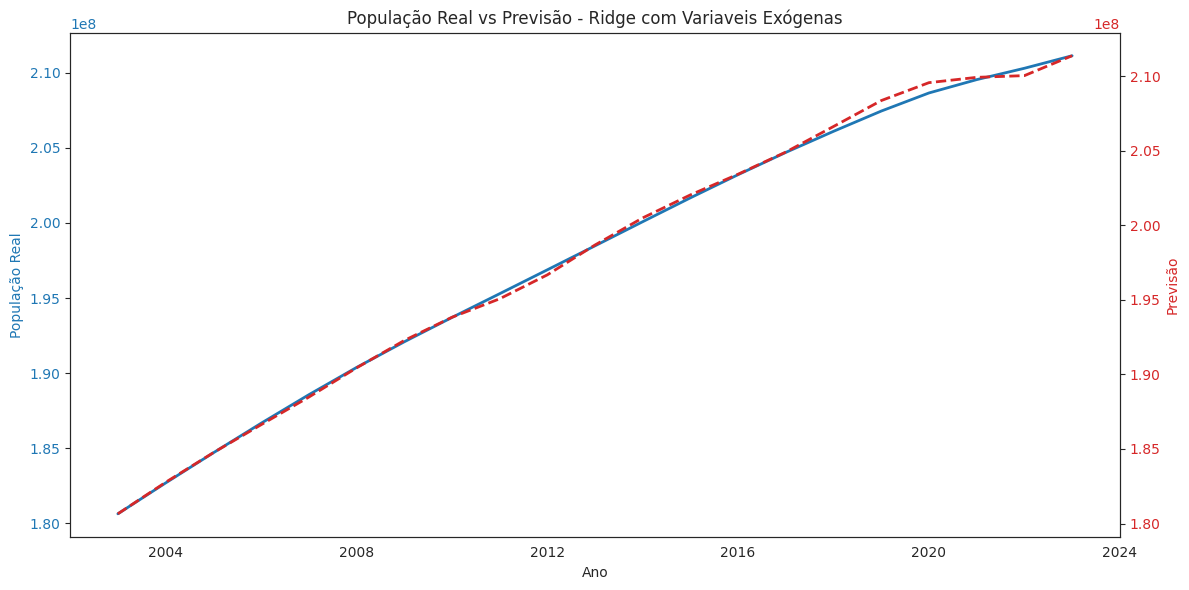

In [ ]:
forecasters_dict = {f.regressor.__class__.__name__: f for f in forecaster}

for i in modelos_anaisar:
    previsoes_lr = lista_previsoes_backtesting[i][['pred']]

    # Alinha com a população real
    y_real = populacao_total.loc[previsoes_lr.index]

    # Plot com dois eixos y
    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.set_xlabel('Ano')
    ax1.set_ylabel('População Real', color='tab:blue')
    ax1.plot(y_real, label='População Real', color='tab:blue', linewidth=2)
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Previsão', color='tab:red')
    ax2.plot(previsoes_lr, label=f'Previsão - {i}', color='tab:red', linestyle='--', linewidth=2)
    ax2.tick_params(axis='y', labelcolor='tab:red')

    plt.title(f'População Real vs Previsão - {i} com Variaveis Exógenas')
    fig.tight_layout()
    plt.show()

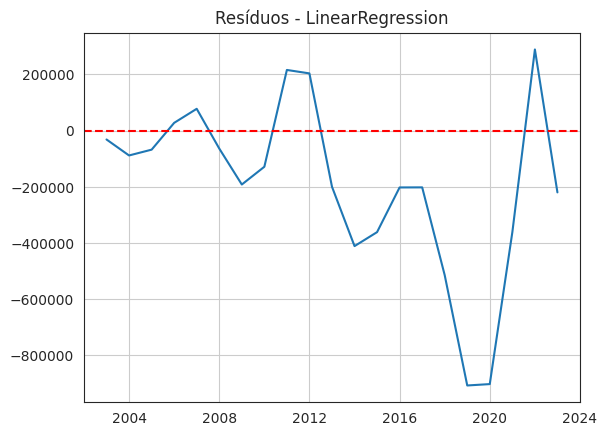

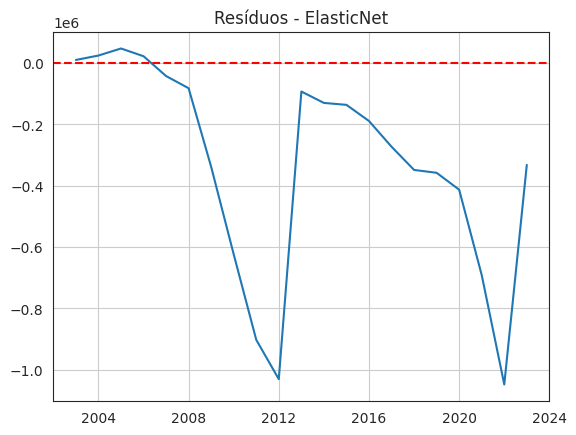

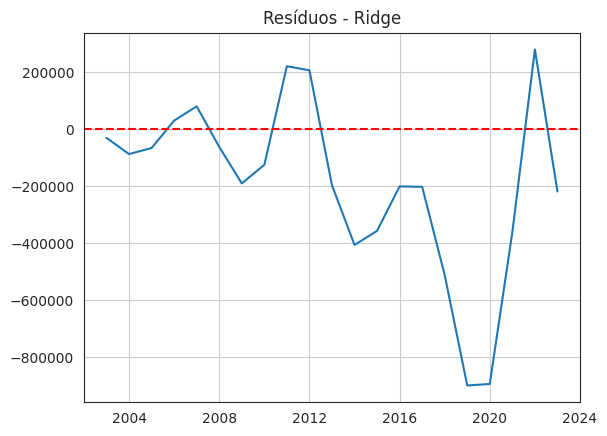

In [ ]:
for i in modelos_anaisar:
    residuos = populacao_total - lista_previsoes_backtesting[i]['pred']
    plt.figure()
    plt.title(f'Resíduos - {i}')
    plt.plot(residuos)
    plt.axhline(0, color='red', linestyle='--')
    plt.grid()
    plt.show()

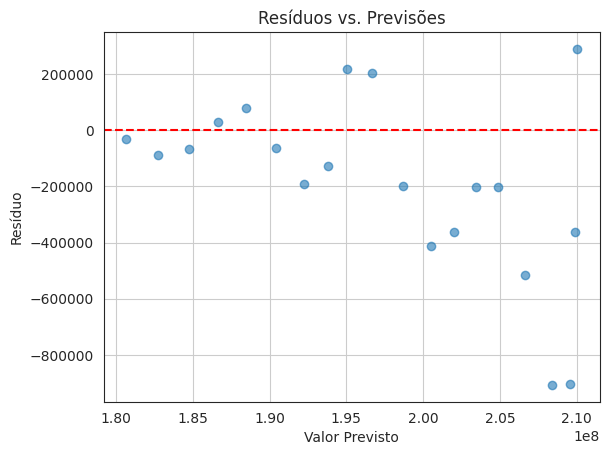

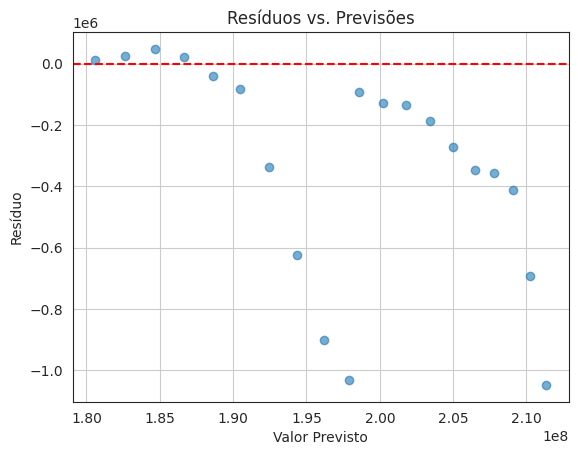

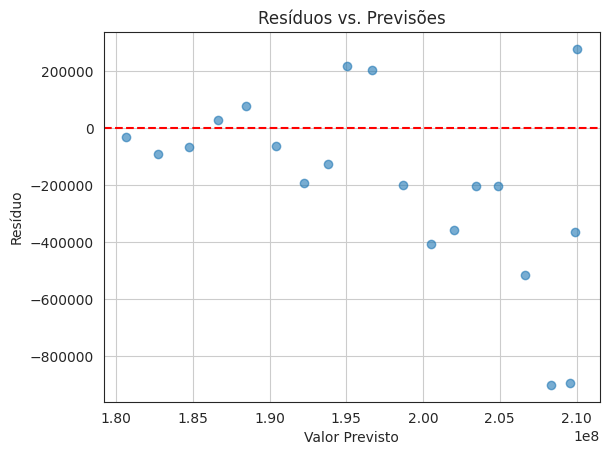

In [ ]:
for i in modelos_anaisar:
    df_pred = lista_previsoes_backtesting[i]
    df_pred['real'] = df_pred['Populacao_Anterior'].shift(-1)
    df_pred['residuo'] = df_pred['real'] - df_pred['pred']
    # Remove linhas com NaN (última geralmente fica com NaN)
    df_pred = df_pred.dropna(subset=['real', 'pred'])
    plt.scatter(df_pred['pred'], df_pred['residuo'], alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.title('Resíduos vs. Previsões')
    plt.xlabel('Valor Previsto')
    plt.ylabel('Resíduo')
    plt.grid()
    plt.show()